# RAGLO-Bark A6 — Report-Ready Complete Training and Deployment Notebook

This notebook trains only the complete **RAGLO-Bark A6** model, evaluates the four known species, calibrates eucalyptus as an unknown species, generates report-ready statistics and graphs, exports deployment weights, verifies reload consistency, and provides prototype inference.

```text
Known bark dataset → A6 two-stage training → validation checkpoint selection
→ one-time closed-set test → eucalyptus open-set calibration/test
→ statistics + graphs → deployment artifact → prototype web interface
```

Eucalyptus is never added as a fifth training class.

## Before running

Use this Drive structure:

```text
RAGLO_Bark/
├── bark_dataset/
├── bark_metadata.csv
├── unknown_dataset/
│   ├── calibration/eucalyptus/
│   └── test/eucalyptus/
└── outputs/
```

The notebook has one A6 training entry point. `TRAINING_MODE="auto"` trains when no final checkpoint exists and loads it on later runs. Use `"fresh"` only when intentionally retraining from the beginning.

The current test set has already been viewed in earlier experiments. A newly retrained model ideally requires a new untouched external test set for a strictly new final research claim.

# 1 — Colab runtime setup

In [ ]:
import importlib.util, subprocess, sys
required = {"timm":"timm", "transformers":"transformers", "pandas":"pandas", "sklearn":"scikit-learn",
            "matplotlib":"matplotlib", "seaborn":"seaborn", "PIL":"Pillow", "cv2":"opencv-python-headless",
            "tqdm":"tqdm", "safetensors":"safetensors", "gradio":"gradio"}
missing = [pkg for module, pkg in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import platform, torch, torchvision, timm, transformers, gradio
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("TIMM:", timm.__version__, "| transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name, "| memory GiB:", round(props.total_memory / 2**30, 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", DEVICE)
print("Note: pretrained weights are downloaded on first use.")
print("Gradio:", gradio.__version__)


Python: 3.12.13
PyTorch: 2.11.0+cu128 | torchvision: 0.26.0+cu128
TIMM: 1.0.28 | transformers: 5.13.1
CUDA available: True
GPU: Tesla T4 | memory GiB: 14.56
Selected device: cuda
Note: pretrained weights are downloaded on first use.
Gradio: 6.20.0


# 2 — Mount Google Drive and configure paths

In [ ]:
from pathlib import Path
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

PROJECT_ROOT = Path("/content/drive/MyDrive/RAGLO_Bark")
DATASET_ROOT = PROJECT_ROOT / "bark_dataset"
METADATA_PATH = PROJECT_ROOT / "bark_metadata.csv"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
CHECKPOINT_ROOT = OUTPUT_ROOT / "checkpoints"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
REPORT_ROOT = OUTPUT_ROOT / "reports"
EXPORT_ROOT = OUTPUT_ROOT / "exported_model"
for output_dir in (OUTPUT_ROOT, CHECKPOINT_ROOT, FIGURE_ROOT, REPORT_ROOT, EXPORT_ROOT):
    output_dir.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/RAGLO_Bark


# 3 — RAGLO experiment configuration

Change only `EXPERIMENT_TO_RUN` for normal ablation training.

Valid values:

```text
"A3", "A4", "A5", "A6", or None
```

Use `None` when loading a completed checkpoint for evaluation, inference, prototype generation, or export.

In [ ]:
from dataclasses import dataclass, asdict
from typing import Any, Optional, Sequence, Callable

CLASS_NAMES = ["mahogany", "pine", "rubber", "teak"]
CLASS_TO_IDX = {"mahogany": 0, "pine": 1, "rubber": 2, "teak": 3}
SCIENTIFIC_NAMES = {
    "mahogany": "Swietenia macrophylla",
    "pine": "Pinus spp.",
    "rubber": "Hevea brasiliensis",
    "teak": "Tectona grandis",
}
DINO_MODEL_ID = "facebook/dinov2-small"
CONVNEXT_MODEL_ID = None

@dataclass
class FinalConfig:
    RANDOM_SEED: int = 42
    GLOBAL_IMAGE_SIZE: int = 384
    LOCAL_IMAGE_SIZE: int = 224
    NUMBER_OF_PATCHES: int = 4
    BATCH_SIZE: int = 16
    CLASSES_PER_BATCH: int = 4
    SAMPLES_PER_CLASS: int = 4
    NUM_WORKERS: int = 2
    HEAD_WARMUP_EPOCHS: int = 5
    MAX_EPOCHS: int = 50
    EARLY_STOPPING_PATIENCE: int = 8
    BACKBONE_LR: float = 1e-5
    HEAD_LR: float = 3e-4
    WEIGHT_DECAY: float = 1e-4
    LABEL_SMOOTHING: float = 0.1
    GRADIENT_CLIP_NORM: float = 1.0
    SUPCON_WEIGHT: float = 0.3
    CONSISTENCY_WEIGHT: float = 0.2
    AUX_CLASSIFICATION_WEIGHT: float = 0.1
    SUPCON_TEMPERATURE: float = 0.07
    EMBEDDING_DIM: int = 256
    DROPOUT: float = 0.2
    USE_MIXED_PRECISION: bool = True
    GRADIENT_ACCUMULATION_STEPS: int = 1

    # auto | fresh | resume | load
    TRAINING_MODE: str = "auto"
    RUN_FINAL_TEST: bool = True
    ALLOW_TEST_RERUN: bool = False
    RUN_OPEN_SET: bool = True
    FORCE_RECALIBRATE_OPEN_SET: bool = True
    RUN_EXPORT: bool = True
    VERIFY_EXPORT: bool = True
    RUN_INTERACTIVE_INFERENCE: bool = False
    RUN_GRADIO_DEMO: bool = False

    ENERGY_TEMPERATURE: float = 1.0
    BOOTSTRAP_SAMPLES: int = 2000
    LATENCY_REPEATS: int = 30
    FAST_DEV_RUN: bool = False
    RUN_REAL_MODEL_SMOKE_TEST: bool = False
    RESUME_TRAINING: bool = False

CFG = FinalConfig()
if CFG.TRAINING_MODE not in {"auto", "fresh", "resume", "load"}:
    raise ValueError("Invalid TRAINING_MODE")
if CFG.FAST_DEV_RUN:
    CFG.HEAD_WARMUP_EPOCHS = 1
    CFG.MAX_EPOCHS = 1
    CFG.BOOTSTRAP_SAMPLES = 100
MAX_BATCHES_PER_PHASE = 2 if CFG.FAST_DEV_RUN else None
FINAL_TEST_UNLOCK = CFG.RUN_FINAL_TEST
print(asdict(CFG))

{'RANDOM_SEED': 42, 'GLOBAL_IMAGE_SIZE': 384, 'LOCAL_IMAGE_SIZE': 224, 'NUMBER_OF_PATCHES': 4, 'BATCH_SIZE': 16, 'CLASSES_PER_BATCH': 4, 'SAMPLES_PER_CLASS': 4, 'NUM_WORKERS': 2, 'HEAD_WARMUP_EPOCHS': 5, 'MAX_EPOCHS': 50, 'EARLY_STOPPING_PATIENCE': 8, 'BACKBONE_LR': 1e-05, 'HEAD_LR': 0.0003, 'WEIGHT_DECAY': 0.0001, 'LABEL_SMOOTHING': 0.1, 'GRADIENT_CLIP_NORM': 1.0, 'SUPCON_WEIGHT': 0.3, 'CONSISTENCY_WEIGHT': 0.2, 'AUX_CLASSIFICATION_WEIGHT': 0.1, 'SUPCON_TEMPERATURE': 0.07, 'EMBEDDING_DIM': 256, 'DROPOUT': 0.2, 'USE_MIXED_PRECISION': True, 'GRADIENT_ACCUMULATION_STEPS': 1, 'TRAINING_MODE': 'auto', 'RUN_FINAL_TEST': True, 'ALLOW_TEST_RERUN': False, 'RUN_OPEN_SET': True, 'FORCE_RECALIBRATE_OPEN_SET': True, 'RUN_EXPORT': True, 'VERIFY_EXPORT': True, 'RUN_INTERACTIVE_INFERENCE': False, 'RUN_GRADIO_DEMO': False, 'ENERGY_TEMPERATURE': 1.0, 'BOOTSTRAP_SAMPLES': 2000, 'LATENCY_REPEATS': 30, 'FAST_DEV_RUN': False, 'RUN_REAL_MODEL_SMOKE_TEST': False, 'RESUME_TRAINING': False}


# 4 — Reproducibility

In [ ]:
import os, random, warnings, numpy as np
def seed_everything(seed: int) -> None:
    '''Seed Python, NumPy, and PyTorch without making unsupported kernels fatal.'''
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id: int) -> None:
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    random.seed(worker_seed); np.random.seed(worker_seed)

seed_everything(CFG.RANDOM_SEED)
DATALOADER_GENERATOR = torch.Generator().manual_seed(CFG.RANDOM_SEED)
warnings.warn("Exact GPU reproducibility is not always guaranteed.")

/tmp/ipykernel_1468/3526096441.py:17: UserWarning: Exact GPU reproducibility is not always guaranteed.
  warnings.warn("Exact GPU reproducibility is not always guaranteed.")


# 5 — Load and validate metadata

In [ ]:
import pandas as pd
REQUIRED_COLUMNS = ["image_path","species","scientific_name","image_width","image_height","exact_hash",
                    "perceptual_hash","redundancy_group","quality_status","split"]

def validate_metadata(frame: pd.DataFrame, dataset_root: Path, expected_rows: int = 723) -> None:
    '''Validate metadata and redundancy-controlled split integrity.'''
    missing = set(REQUIRED_COLUMNS) - set(frame.columns)
    assert not missing, f"Missing metadata columns: {sorted(missing)}"
    assert frame.image_path.notna().all() and frame.image_path.is_unique
    absent = [p for p in frame.image_path if not (dataset_root / Path(p)).is_file()]
    assert not absent, f"Missing image paths (first five): {absent[:5]}"
    assert set(frame.species) == set(CLASS_NAMES), "Expected all and only the four configured classes"
    assert frame.species.notna().all() and frame.scientific_name.notna().all()
    assert frame.split.notna().all() and set(frame.split) <= {"train","validation","test","excluded"}
    assert not ((frame.quality_status == "reject") & frame.split.isin(["train","validation","test"])).any()
    active = frame[frame.split.isin(["train","validation","test"])]
    assert active.groupby("redundancy_group").split.nunique().max() <= 1, "Redundancy-group leakage"
    assert active.groupby("exact_hash").split.nunique().max() <= 1, "Exact-hash leakage"
    assert CLASS_TO_IDX == {name: i for i, name in enumerate(CLASS_NAMES)}
    if len(frame) != expected_rows:
        warnings.warn(f"Expected {expected_rows} rows, found {len(frame)}; confirm intentional dataset update.")

if not METADATA_PATH.is_file() or not DATASET_ROOT.is_dir():
    raise FileNotFoundError(f"Required DATASET_ROOT/METADATA_PATH missing: {DATASET_ROOT}, {METADATA_PATH}")
metadata = pd.read_csv(METADATA_PATH)
validate_metadata(metadata, DATASET_ROOT)
print("Total images:", len(metadata)); print(metadata.species.value_counts())
print(metadata.split.value_counts()); print(pd.crosstab(metadata.species, metadata.split))
print(metadata[["image_width","image_height"]].describe())
imbalance_ratio = metadata.species.value_counts().max() / metadata.species.value_counts().min()
print("Class imbalance ratio:", round(imbalance_ratio, 2), "(moderate; expected about 2.52)")
print(metadata[["species","scientific_name"]].drop_duplicates().sort_values("species"))
print("Unique exact hashes:", metadata.exact_hash.nunique())
print("Unique redundancy groups:", metadata.redundancy_group.nunique())

Total images: 723
species
teak        255
pine        245
mahogany    122
rubber      101
Name: count, dtype: int64
split
train         507
validation    108
test          108
Name: count, dtype: int64
split     test  train  validation
species                          
mahogany    18     86          18
pine        37    171          37
rubber      15     71          15
teak        38    179          38
       image_width  image_height
count   723.000000    723.000000
mean   1388.733057   3754.634855
std     482.232983    543.838180
min     272.000000   1284.000000
25%     958.000000   3752.500000
50%    1529.000000   4032.000000
75%    1781.000000   4032.000000
max    2219.000000   4064.000000
Class imbalance ratio: 2.52 (moderate; expected about 2.52)
      species        scientific_name
0    mahogany  Swietenia macrophylla
122      pine             Pinus spp.
367    rubber     Hevea brasiliensis
468      teak        Tectona grandis
Unique exact hashes: 723
Unique redundancy groups: 7

# 6 — Dataset visual audit

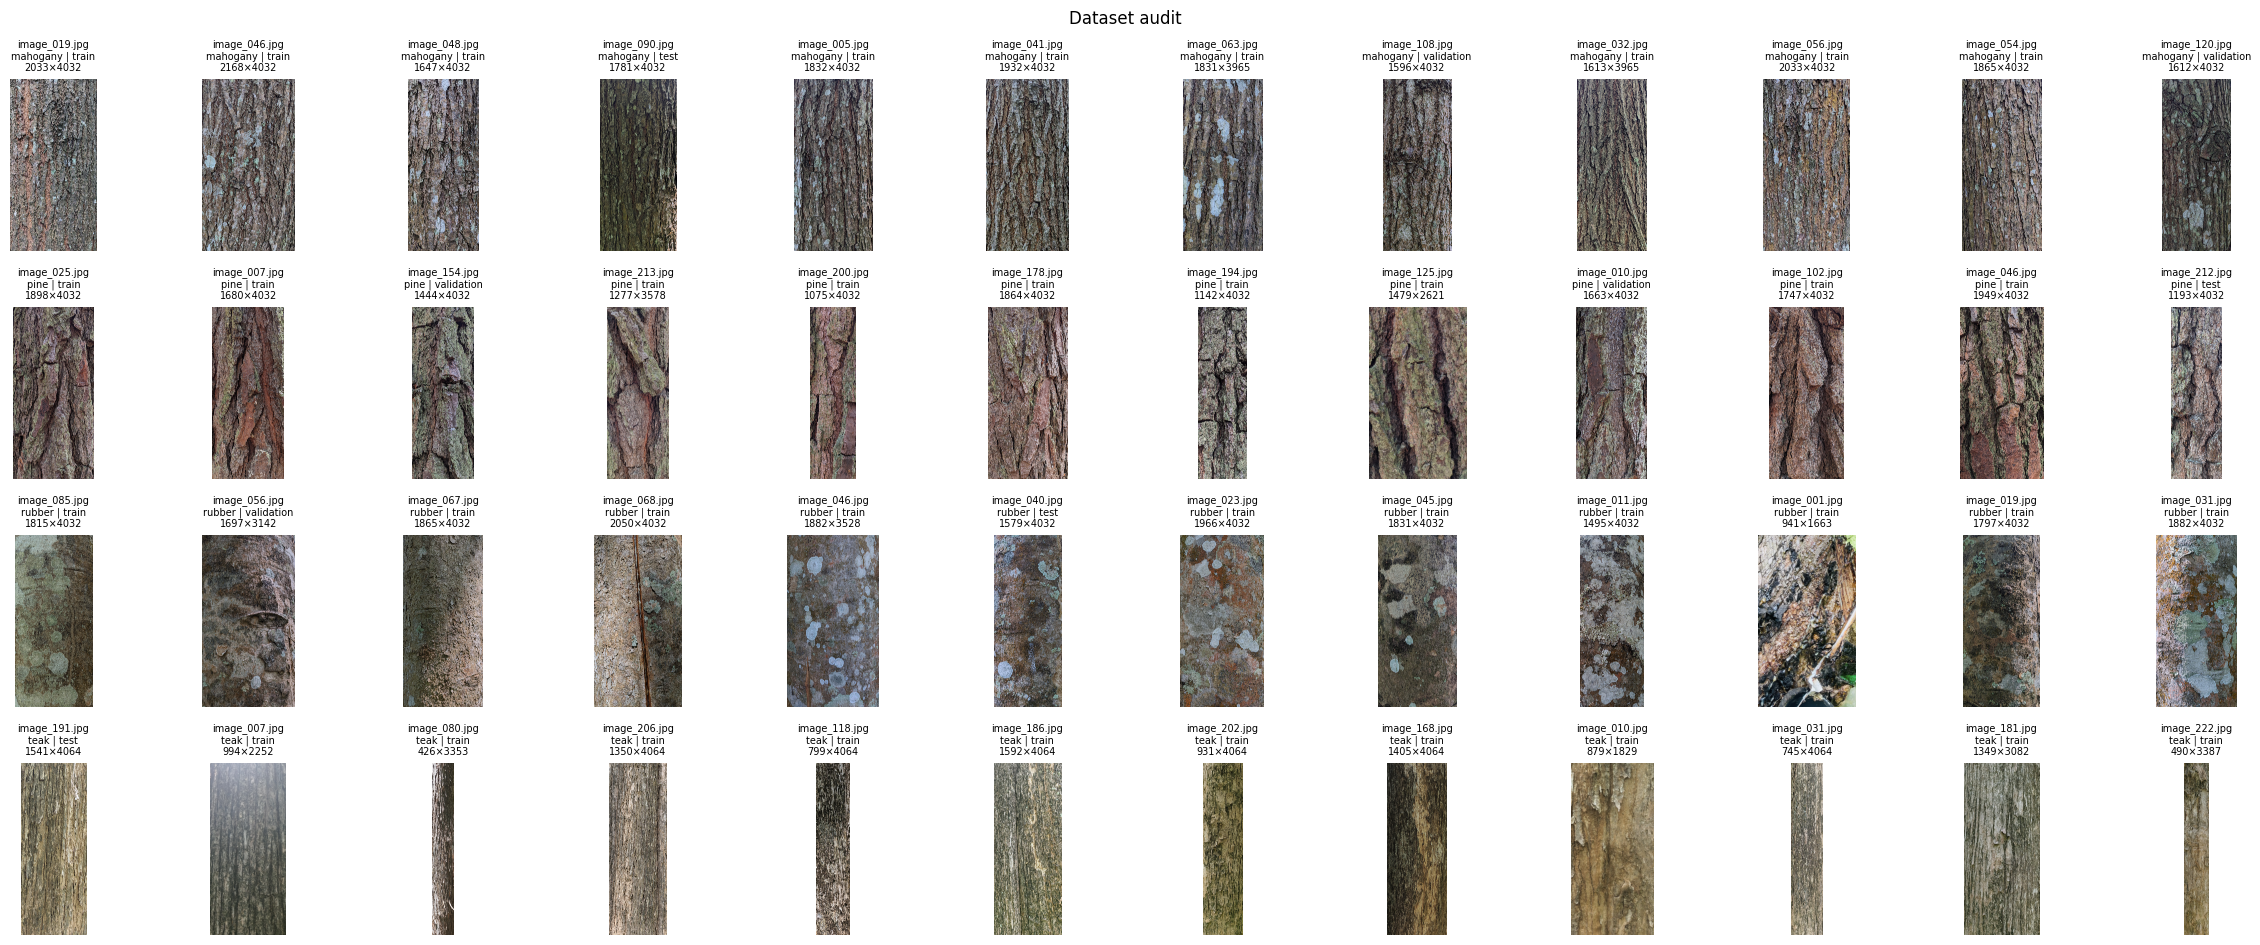

/tmp/ipykernel_1468/495115243.py:28: UserWarning: VISUAL AUDIT NOT CONFIRMED: inspect labels, content, overlays, background cues, and pine consistency.
  warnings.warn("VISUAL AUDIT NOT CONFIRMED: inspect labels, content, overlays, background cues, and pine consistency.")


In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
VISUAL_AUDIT_COMPLETED = False

def show_contact_sheet(frame: pd.DataFrame, per_species: int = 12, seed: int = 42,
                       title: str = "Dataset audit") -> None:
    """Plot safely for empty, one-row, one-column, and uneven class samples."""
    if frame.empty:
        print(f"{title}: no images to display."); return
    groups = [(species, group.sample(min(per_species, len(group)), random_state=seed))
              for species, group in frame.groupby("species") if len(group)]
    if not groups:
        print(f"{title}: no class samples to display."); return
    columns = max(len(group) for _, group in groups)
    fig, axes = plt.subplots(len(groups), columns, figsize=(max(4, columns*2), max(3, len(groups)*2.4)), squeeze=False)
    for ax in axes.flat: ax.axis("off")
    for row_index, (species, rows) in enumerate(groups):
        for column, (_, row) in enumerate(rows.iterrows()):
            with Image.open(DATASET_ROOT / row.image_path) as image:
                axes[row_index, column].imshow(ImageOps.exif_transpose(image).convert("RGB"))
            axes[row_index, column].set_title(
                f"{Path(row.image_path).name}\n{species} | {getattr(row,'split','')}\n"
                f"{getattr(row,'image_width','?')}×{getattr(row,'image_height','?')}", fontsize=7)
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_contact_sheet(metadata)
if not VISUAL_AUDIT_COMPLETED:
    warnings.warn("VISUAL AUDIT NOT CONFIRMED: inspect labels, content, overlays, background cues, and pine consistency.")

# 7 — Validation and calibration subdivision

In [ ]:
from collections import Counter, defaultdict
def grouped_validation_calibration(frame: pd.DataFrame, fraction: float = 0.30, seed: int = 42) -> pd.DataFrame:
    '''Assign whole validation redundancy groups to calibration with species-aware targets.'''
    val = frame[frame.split == "validation"].copy()
    group_rows = [(gid, group) for gid, group in val.groupby("redundancy_group", sort=True)]
    rng = random.Random(seed); rng.shuffle(group_rows)
    target = {s: int(round(n * fraction)) for s, n in val.species.value_counts().items()}
    counts: Counter[str] = Counter(); calibration: set[str] = set()
    for gid, group in sorted(group_rows, key=lambda pair: -len(pair[1])):
        species_counts = Counter(group.species)
        before = sum(abs(counts[s] - target[s]) for s in target)
        after = sum(abs(counts[s] + species_counts[s] - target[s]) for s in target)
        if after < before: calibration.add(gid); counts.update(species_counts)
    val["derived_split"] = np.where(val.redundancy_group.isin(calibration), "known_calibration", "model_validation")
    return val[["image_path","species","redundancy_group","derived_split"]]

validation_assignment = grouped_validation_calibration(metadata, seed=CFG.RANDOM_SEED)
validation_assignment.to_csv(REPORT_ROOT / "validation_calibration_assignment.csv", index=False)
experiment_metadata = metadata.merge(validation_assignment[["image_path","derived_split"]], on="image_path", how="left")
experiment_metadata["experiment_split"] = experiment_metadata.derived_split.fillna(experiment_metadata.split)
for name in ["train","model_validation","known_calibration","test"]:
    print("\n", name); print(experiment_metadata[experiment_metadata.experiment_split == name].species.value_counts())
assert experiment_metadata[experiment_metadata.split == "test"].experiment_split.eq("test").all()


 train
species
teak        179
pine        171
mahogany     86
rubber       71
Name: count, dtype: int64

 model_validation
species
teak        27
pine        26
mahogany    13
rubber      11
Name: count, dtype: int64

 known_calibration
species
pine        11
teak        11
mahogany     5
rubber       4
Name: count, dtype: int64

 test
species
teak        38
pine        37
mahogany    18
rubber      15
Name: count, dtype: int64


# 8 — Aspect-preserving preprocessing

In [ ]:
from torchvision import transforms
from torchvision.transforms import functional as TF
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)
NEUTRAL_PAD = tuple(round(value * 255) for value in IMAGENET_MEAN)

def load_rgb_image(path: Path) -> Image.Image:
    """Load one file, apply EXIF orientation, decode, and return independent RGB pixels."""
    try:
        with Image.open(path) as image:
            corrected = ImageOps.exif_transpose(image).convert("RGB"); corrected.load(); return corrected.copy()
    except Exception as exc:
        raise RuntimeError(f"Cannot load image '{path}': {exc}") from exc

def aspect_resize_pad(image: Image.Image, target_size: int,
                      fill: tuple[int, int, int] | None = None) -> Image.Image:
    """Preserve aspect ratio, fit inside a square, and symmetrically pad."""
    if target_size <= 0 or image.width <= 0 or image.height <= 0:
        raise ValueError("Image dimensions and target_size must be positive")
    image = image.convert("RGB"); fill = NEUTRAL_PAD if fill is None else fill
    scale = min(target_size / image.width, target_size / image.height)
    new_size = (max(1, round(image.width * scale)), max(1, round(image.height * scale)))
    resized = image.resize(new_size, Image.Resampling.BICUBIC)
    canvas = Image.new("RGB", (target_size, target_size), fill)
    canvas.paste(resized, ((target_size-resized.width)//2, (target_size-resized.height)//2))
    return canvas

NORMALIZE = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
DETERMINISTIC_TENSOR = transforms.Compose([transforms.ToTensor(), NORMALIZE])

# 9 — Data augmentation

In [ ]:
class RandomJPEG:
    """Occasionally simulate mild JPEG compression without altering source files."""
    def __init__(self, probability: float = 0.15, quality=(70, 95)): self.p, self.quality = probability, quality
    def __call__(self, image: Image.Image) -> Image.Image:
        if random.random() >= self.p: return image
        import io
        buffer = io.BytesIO(); image.save(buffer, "JPEG", quality=random.randint(*self.quality)); buffer.seek(0)
        with Image.open(buffer) as decoded: return decoded.convert("RGB").copy()

# Both global and local PIL images are aspect-prepared before these transforms.
TRAIN_GLOBAL_AUGMENT = transforms.Compose([
    transforms.RandomResizedCrop(CFG.GLOBAL_IMAGE_SIZE, scale=(0.78,1.0), ratio=(0.9,1.1), antialias=True),
    transforms.RandomRotation(10, fill=NEUTRAL_PAD), transforms.RandomHorizontalFlip(0.4),
    transforms.ColorJitter(0.15,0.15,0.12,0.03), transforms.RandomPerspective(0.15,p=0.15,fill=NEUTRAL_PAD),
    transforms.RandomApply([transforms.GaussianBlur(3,(0.1,1.0))],p=0.10), transforms.RandomGrayscale(0.05),
    transforms.RandomAdjustSharpness(1.3,p=0.15), RandomJPEG(), transforms.ToTensor(), NORMALIZE,
    transforms.RandomErasing(p=0.15,scale=(0.02,0.08),value="random")])
TRAIN_LOCAL_AUGMENT = transforms.Compose([
    transforms.RandomCrop(CFG.LOCAL_IMAGE_SIZE, padding=max(2,CFG.LOCAL_IMAGE_SIZE//30), fill=NEUTRAL_PAD, padding_mode="constant"),
    transforms.RandomRotation(7,fill=NEUTRAL_PAD), transforms.RandomHorizontalFlip(0.4),
    transforms.ColorJitter(0.12,0.12,0.10,0.02), transforms.RandomPerspective(0.10,p=0.10,fill=NEUTRAL_PAD),
    transforms.RandomApply([transforms.GaussianBlur(3,(0.1,0.8))],p=0.08), RandomJPEG(0.10),
    transforms.ToTensor(), NORMALIZE, transforms.RandomErasing(p=0.10,scale=(0.02,0.06),value="random")])

# 10 — Global and local patch extraction

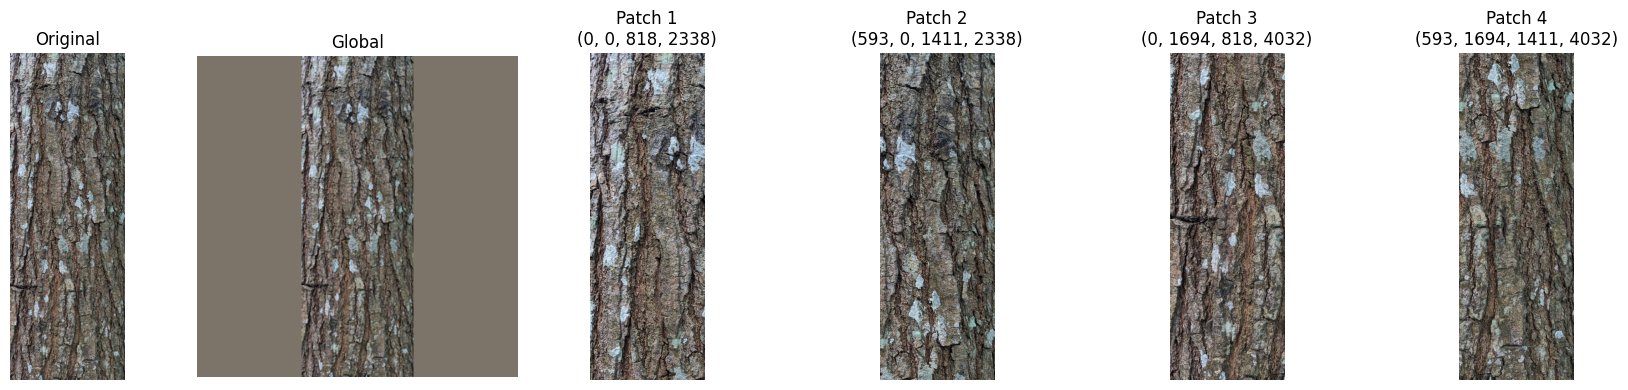

In [ ]:
def extract_four_patches(image: Image.Image, training: bool=False, rng: Optional[random.Random]=None):
    '''Return four PIL crops and `(left, top, right, bottom)` coordinates.'''
    rng = rng or random
    width, height = image.size; patch_w = max(1, int(width*0.58)); patch_h = max(1, int(height*0.58))
    anchors = [(0,0),(width-patch_w,0),(0,height-patch_h),(width-patch_w,height-patch_h)]
    coordinates=[]
    for left, top in anchors:
        if training:
            left = min(max(0,left+rng.randint(-max(1,width//12),max(1,width//12))), width-patch_w)
            top = min(max(0,top+rng.randint(-max(1,height//12),max(1,height//12))), height-patch_h)
        coordinates.append((left,top,left+patch_w,top+patch_h))
    return [image.crop(box) for box in coordinates], coordinates

def visualize_inputs(image_path: Path) -> None:
    image=load_rgb_image(image_path); global_view=aspect_resize_pad(image,CFG.GLOBAL_IMAGE_SIZE)
    patches,boxes=extract_four_patches(image,False); fig,axes=plt.subplots(1,6,figsize=(18,4))
    axes[0].imshow(image); axes[0].set_title("Original"); axes[1].imshow(global_view); axes[1].set_title("Global")
    for i,(patch,box) in enumerate(zip(patches,boxes)): axes[i+2].imshow(patch); axes[i+2].set_title(f"Patch {i+1}\n{box}")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

visualize_inputs(DATASET_ROOT / metadata.iloc[0].image_path)

# 11 — Multi-scale PyTorch dataset

In [ ]:
from torch.utils.data import Dataset
class BarkGlobalDataset(Dataset):
    """Stream deterministic or augmented global images without extracting patches."""
    def __init__(self, frame, dataset_root: Path, training=False, error_log: Optional[Path]=None):
        self.frame=frame.reset_index(drop=True); self.root=dataset_root; self.training=training; self.error_log=error_log
    def __len__(self): return len(self.frame)
    def _load(self,index):
        row=self.frame.iloc[index]; path=self.root/row.image_path
        try: return row,load_rgb_image(path)
        except Exception as exc:
            if self.error_log:
                with self.error_log.open("a",encoding="utf-8") as handle: handle.write(f"{row.image_path}\t{exc}\n")
            raise
    def __getitem__(self,index):
        row,image=self._load(index); prepared=aspect_resize_pad(image,CFG.GLOBAL_IMAGE_SIZE)
        tensor=TRAIN_GLOBAL_AUGMENT(prepared) if self.training else DETERMINISTIC_TENSOR(prepared)
        return {"global_image":tensor,"label":CLASS_TO_IDX[row.species],"species":row.species,"image_path":row.image_path}

class BarkMultiScaleDataset(BarkGlobalDataset):
    """Stream one aspect-preserved global view and four aspect-preserved local patches."""
    def __getitem__(self,index):
        row,image=self._load(index); global_prepared=aspect_resize_pad(image,CFG.GLOBAL_IMAGE_SIZE)
        global_tensor=TRAIN_GLOBAL_AUGMENT(global_prepared) if self.training else DETERMINISTIC_TENSOR(global_prepared)
        patches,_=extract_four_patches(image,self.training)
        local=[]
        for patch in patches:
            prepared=aspect_resize_pad(patch,CFG.LOCAL_IMAGE_SIZE)
            local.append(TRAIN_LOCAL_AUGMENT(prepared) if self.training else DETERMINISTIC_TENSOR(prepared))
        return {"global_image":global_tensor,"local_patches":torch.stack(local),"label":CLASS_TO_IDX[row.species],
                "species":row.species,"image_path":row.image_path}

# 12 — RAGLO multi-scale DataLoaders

The training loader uses class-balanced batches to ensure positive pairs for supervised contrastive learning. Cross-entropy is therefore not additionally class weighted, avoiding double balancing.

In [ ]:
from torch.utils.data import DataLoader, Sampler

def stratified_fast_subset(frame, n_per_class=4):
    if not CFG.FAST_DEV_RUN:
        return frame.copy()
    return pd.concat(
        [
            group.sample(
                min(n_per_class, len(group)),
                random_state=CFG.RANDOM_SEED,
            )
            for _, group in frame.groupby("species")
        ],
        ignore_index=True,
    )

class ClassBalancedBatchSampler(Sampler[list[int]]):
    """Reproducible class-balanced batches with SupCon positive pairs."""

    def __init__(
        self,
        labels,
        classes_per_batch=4,
        samples_per_class=4,
        seed=42,
        drop_last=False,
    ):
        self.labels = np.asarray(labels, dtype=int)
        self.classes_per_batch = classes_per_batch
        self.samples_per_class = samples_per_class
        self.seed = seed
        self.drop_last = drop_last
        self.epoch = 0
        self.by_class = {
            int(label): np.flatnonzero(self.labels == label)
            for label in np.unique(self.labels)
        }

        if classes_per_batch > len(self.by_class):
            raise ValueError("classes_per_batch exceeds available classes")
        if samples_per_class < 2:
            raise ValueError(
                "Supervised contrastive learning requires at least "
                "two samples per selected class"
            )

    @property
    def batch_size(self):
        return self.classes_per_batch * self.samples_per_class

    def __len__(self):
        if self.drop_last:
            return max(1, len(self.labels) // self.batch_size)
        return max(1, int(np.ceil(len(self.labels) / self.batch_size)))

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        classes = np.array(sorted(self.by_class))
        pools = {
            class_id: rng.permutation(self.by_class[class_id]).tolist()
            for class_id in classes
        }
        positions = {class_id: 0 for class_id in classes}

        for _ in range(len(self)):
            selected = rng.choice(
                classes,
                size=self.classes_per_batch,
                replace=False,
            )
            batch = []

            for class_id in selected:
                class_id = int(class_id)
                pool = pools[class_id]
                position = positions[class_id]

                if position + self.samples_per_class > len(pool):
                    pool = rng.permutation(
                        self.by_class[class_id]
                    ).tolist()
                    pools[class_id] = pool
                    position = 0

                chosen = pool[
                    position: position + self.samples_per_class
                ]

                if len(chosen) < self.samples_per_class:
                    chosen += rng.choice(
                        self.by_class[class_id],
                        self.samples_per_class - len(chosen),
                        replace=True,
                    ).tolist()

                positions[class_id] = position + self.samples_per_class
                batch.extend(chosen)

            rng.shuffle(batch)
            yield batch

frames = {
    name: experiment_metadata[
        experiment_metadata.experiment_split == name
    ].copy()
    for name in [
        "train",
        "model_validation",
        "known_calibration",
        "test",
    ]
}
frames["train"] = stratified_fast_subset(frames["train"])

common_loader_kwargs = dict(
    num_workers=CFG.NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=CFG.NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
    generator=DATALOADER_GENERATOR,
)

multiscale_datasets = {
    name: BarkMultiScaleDataset(
        frame,
        DATASET_ROOT,
        training=(name == "train"),
        error_log=REPORT_ROOT / "runtime_image_errors.log",
    )
    for name, frame in frames.items()
}

balanced_sampler = ClassBalancedBatchSampler(
    frames["train"].species.map(CLASS_TO_IDX),
    CFG.CLASSES_PER_BATCH,
    CFG.SAMPLES_PER_CLASS,
    CFG.RANDOM_SEED,
)

multiscale_loaders = {
    "train": DataLoader(
        multiscale_datasets["train"],
        batch_sampler=balanced_sampler,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=CFG.NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
    )
}

for name in ["model_validation", "known_calibration", "test"]:
    multiscale_loaders[name] = DataLoader(
        multiscale_datasets[name],
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        **common_loader_kwargs,
    )

# Deterministic, non-augmented reference loader for class prototypes.
train_reference_dataset = BarkMultiScaleDataset(
    frames["train"],
    dataset_root=DATASET_ROOT,
    training=False,
    error_log=REPORT_ROOT / "runtime_image_errors.log",
)
train_reference_loader = DataLoader(
    train_reference_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    **common_loader_kwargs,
)

print("RAGLO loaders:", list(multiscale_loaders))
print("Balanced training batch size:", balanced_sampler.batch_size)
print(
    "Train / model validation / calibration / test:",
    {name: len(frame) for name, frame in frames.items()},
)

RAGLO loaders: ['train', 'model_validation', 'known_calibration', 'test']
Balanced training batch size: 16
Train / model validation / calibration / test: {'train': 507, 'model_validation': 77, 'known_calibration': 31, 'test': 108}


# 13 — DINOv2 and ConvNeXt V2 feature encoders

In [ ]:
def select_convnextv2_atto_name(pretrained: bool = True) -> str:
    """Resolve a valid TIMM ConvNeXt V2-Atto checkpoint."""
    pattern = "convnextv2_atto*"
    candidates = timm.list_models(pattern, pretrained=pretrained)

    if not candidates and pretrained:
        candidates = timm.list_models(pattern, pretrained=False)

    if candidates:
        selected = sorted(
            candidates,
            key=lambda name: ("fcmae" not in name, name),
        )[0]
    else:
        available = timm.list_models(
            "convnextv2*",
            pretrained=pretrained,
        )
        print("Available ConvNeXt V2 models:", available)
        fallback = [name for name in available if "nano" in name]

        if not fallback:
            raise RuntimeError(
                "No ConvNeXt V2-Atto or documented Nano fallback "
                "exists in the installed TIMM version"
            )

        selected = sorted(fallback)[0]
        warnings.warn(
            "ConvNeXt V2-Atto unavailable; using documented "
            f"Nano fallback: {selected}"
        )

    print("Selected TIMM local encoder:", selected)
    return selected

def build_convnext_feature_encoder(pretrained: bool = True):
    global CONVNEXT_MODEL_ID

    CONVNEXT_MODEL_ID = select_convnextv2_atto_name(pretrained)

    model = timm.create_model(
        CONVNEXT_MODEL_ID,
        pretrained=pretrained,
        num_classes=0,
        global_pool="avg",
    )

    if not hasattr(model, "num_features"):
        raise RuntimeError(
            "TIMM feature encoder does not expose num_features"
        )

    return model

# 14 — RAGLO-Bark architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

class TinyTokenEncoder(nn.Module):
    """Injected smoke-test encoder, not a research model."""
    def __init__(self,dim=32): super().__init__(); self.conv=nn.Conv2d(3,dim,8,8); self.config=type("Config",(),{"hidden_size":dim})()
    def forward(self,pixel_values,return_dict=True):
        x=self.conv(pixel_values).flatten(2).transpose(1,2); cls=x.mean(1,keepdim=True)
        return type("Output",(),{"last_hidden_state":torch.cat([cls,x],1)})()
class TinyStageEncoder(nn.Module):
    def __init__(self,dim=24):
        super().__init__(); self.num_features=dim; self.stem=nn.Conv2d(3,dim,3,2,1)
        self.stages=nn.ModuleList([nn.Sequential(nn.Conv2d(dim,dim,3,1,1),nn.GELU()) for _ in range(4)])
        self.pool=nn.AdaptiveAvgPool2d(1)
    def forward(self,x):
        x=self.stem(x)
        for stage in self.stages: x=stage(x)
        return self.pool(x).flatten(1)

class RAGLOBarkModel(nn.Module):
    """Global–local model with separate classification and contrastive paths."""
    def __init__(self,num_classes=4,embedding_dim=256,pretrained=True,global_encoder=None,local_encoder=None,
                 use_attention=True,fusion_mode="gated"):
        super().__init__(); self.use_attention=use_attention; self.fusion_mode=fusion_mode
        self.global_encoder=global_encoder or AutoModel.from_pretrained(DINO_MODEL_ID)
        self.local_encoder=local_encoder or build_convnext_feature_encoder(pretrained)
        global_dim=self.global_encoder.config.hidden_size*2; local_dim=self.local_encoder.num_features
        self.global_projection=nn.Sequential(nn.Linear(global_dim,256),nn.GELU(),nn.Dropout(CFG.DROPOUT))
        self.local_projection=nn.Sequential(nn.Linear(local_dim,256),nn.GELU(),nn.Dropout(CFG.DROPOUT))
        self.patch_attention=nn.Sequential(nn.Linear(256,128),nn.Tanh(),nn.Linear(128,1))
        self.gate_mlp=nn.Sequential(nn.Linear(512,256),nn.GELU(),nn.Linear(256,256))
        self.fusion_norm=nn.LayerNorm(256); self.fusion_dropout=nn.Dropout(CFG.DROPOUT)
        self.fused_projection=nn.Sequential(nn.Linear(256,256),nn.GELU())
        self.embedding_head=nn.Linear(256,embedding_dim)
        self.fused_classifier=nn.Linear(256,num_classes)
        self.global_classifier=nn.Linear(256,num_classes); self.local_classifier=nn.Linear(256,num_classes)
    def forward(self,global_image,local_patches):
        tokens=self.global_encoder(pixel_values=global_image,return_dict=True).last_hidden_state
        global_feature=self.global_projection(torch.cat([tokens[:,0],tokens[:,1:].mean(1)],1))
        batch,patches,channels,height,width=local_patches.shape
        if patches!=CFG.NUMBER_OF_PATCHES: raise ValueError(f"Expected {CFG.NUMBER_OF_PATCHES} patches, got {patches}")
        local_raw=self.local_encoder(local_patches.reshape(batch*patches,channels,height,width))
        local_features=self.local_projection(local_raw).reshape(batch,patches,256)
        attention=F.softmax(self.patch_attention(local_features).squeeze(-1),dim=1) if self.use_attention else torch.full((batch,patches),1/patches,device=local_features.device)
        local_feature=(attention.unsqueeze(-1)*local_features).sum(1)
        gate=torch.full_like(global_feature,0.5) if self.fusion_mode=="average" else torch.sigmoid(self.gate_mlp(torch.cat([global_feature,local_feature],1)))
        fused_feature=self.fused_projection(self.fusion_dropout(self.fusion_norm(gate*global_feature+(1-gate)*local_feature)))
        embedding=F.normalize(self.embedding_head(fused_feature),dim=1)
        return {"fused_logits":self.fused_classifier(fused_feature),"global_logits":self.global_classifier(global_feature),
                "local_logits":self.local_classifier(local_feature),"embedding":embedding,
                "attention_weights":attention,"fusion_gate":gate}

# 15 — Classification, SupCon, and consistency losses

In [ ]:
def supervised_contrastive_loss(embeddings,labels,temperature=0.07):
    '''Stable single-view supervised contrastive loss; ignore anchors without positives.'''
    z=F.normalize(embeddings,dim=1); logits=z@z.T/temperature; logits=logits-logits.max(1,keepdim=True).values.detach()
    eye=torch.eye(len(labels),dtype=torch.bool,device=labels.device); positive=labels[:,None].eq(labels[None,:]) & ~eye
    exp_logits=torch.exp(logits).masked_fill(eye,0); log_prob=logits-torch.log(exp_logits.sum(1,keepdim=True).clamp_min(1e-12))
    positive_count=positive.sum(1); valid=positive_count>0
    if not valid.any(): return embeddings.sum()*0.0
    return -(log_prob.masked_fill(~positive,0).sum(1)[valid]/positive_count[valid]).mean()

def js_consistency_loss(global_logits,local_logits,epsilon=1e-7):
    '''Jensen–Shannon divergence between stable global/local probabilities.'''
    p=F.softmax(global_logits,1).clamp_min(epsilon); q=F.softmax(local_logits,1).clamp_min(epsilon); m=0.5*(p+q)
    return 0.5*((p*(p.log()-m.log())).sum(1)+(q*(q.log()-m.log())).sum(1)).mean()

def compute_losses(outputs,labels,criterion,enable_supcon=True,enable_consistency=True):
    classification=criterion(outputs["fused_logits"],labels); zero=classification*0
    supcon=supervised_contrastive_loss(outputs["embedding"],labels,CFG.SUPCON_TEMPERATURE) if enable_supcon else zero
    consistency=js_consistency_loss(outputs["global_logits"],outputs["local_logits"]) if enable_consistency else zero
    auxiliary=CFG.AUX_CLASSIFICATION_WEIGHT*0.5*(criterion(outputs["global_logits"],labels)+criterion(outputs["local_logits"],labels)) if "global_logits" in outputs else zero
    total=classification+CFG.SUPCON_WEIGHT*supcon+CFG.CONSISTENCY_WEIGHT*consistency+auxiliary
    return {"total":total,"classification":classification,"supcon":supcon,"consistency":consistency,"auxiliary":auxiliary}

synthetic=torch.tensor([[1.,0.],[.9,.1],[0.,1.],[.1,.9]])
assert torch.isfinite(supervised_contrastive_loss(F.normalize(synthetic,dim=1),torch.tensor([0,0,1,1])))
assert torch.isfinite(js_consistency_loss(torch.randn(4,4),torch.randn(4,4)))
print("Loss unit tests passed.")

Loss unit tests passed.


# 16 — Two-stage transfer-learning strategy

In [ ]:
def parameter_report(model):
    total=sum(p.numel() for p in model.parameters()); trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total={total:,} | Trainable={trainable:,} | Frozen={total-trainable:,}"); return total,trainable,total-trainable

def find_convnext_stages(encoder):
    """Locate actual TIMM ConvNeXt stages robustly."""
    for name in ("stages","stages_","blocks"):
        stages=getattr(encoder,name,None)
        if stages is not None and len(stages): return name,stages
    raise RuntimeError("ConvNeXt stages not found; inspect selected TIMM model structure")


def find_dino_blocks(encoder):
    """Locate DINOv2 transformer blocks across supported Transformers layouts."""
    candidates = [
        (
            "encoder.layer",
            getattr(getattr(encoder, "encoder", None), "layer", None),
        ),
        (
            "encoder.layers",
            getattr(getattr(encoder, "encoder", None), "layers", None),
        ),
        ("layer", getattr(encoder, "layer", None)),
        ("layers", getattr(encoder, "layers", None)),
        ("blocks", getattr(encoder, "blocks", None)),
    ]

    for name, blocks in candidates:
        if blocks is not None:
            try:
                if len(blocks) > 0:
                    return name, blocks
            except TypeError:
                continue

    available_children = [
        name for name, _ in encoder.named_children()
    ]
    raise RuntimeError(
        "DINOv2 transformer blocks were not found. "
        f"Top-level child modules: {available_children}"
    )


def configure_dino_phase(model, phase="warmup"):
    """Optional helper retained for compatibility with the shared trainer."""
    if phase not in {"warmup", "partial"}:
        raise ValueError("phase must be 'warmup' or 'partial'")

    for parameter in model.encoder.parameters():
        parameter.requires_grad = False

    unfrozen = []

    if phase == "partial":
        prefix, blocks = find_dino_blocks(model.encoder)

        if len(blocks) < 2:
            raise RuntimeError(
                "DINOv2 has fewer than two transformer blocks"
            )

        start_index = len(blocks) - 2

        for index, block in enumerate(
            blocks[-2:],
            start=start_index,
        ):
            for parameter in block.parameters():
                parameter.requires_grad = True

            unfrozen.append(
                f"encoder.{prefix}.{index}"
            )

    print(
        "DINO phase",
        phase,
        "unfrozen:",
        unfrozen or "heads only",
    )

    return unfrozen


def configure_raglo_phase(model,phase="warmup"):
    for encoder in (model.global_encoder,model.local_encoder):
        for parameter in encoder.parameters(): parameter.requires_grad=False
    unfrozen=[]
    if phase=="partial":
        dino_prefix,dino_blocks=find_dino_blocks(model.global_encoder)
        if len(dino_blocks)<2: raise RuntimeError("DINOv2 has fewer than two blocks")
        for index,block in enumerate(dino_blocks[-2:],start=len(dino_blocks)-2):
            for parameter in block.parameters(): parameter.requires_grad=True
            unfrozen.append(f"global_encoder.{dino_prefix}.{index}")
        stage_prefix,stages=find_convnext_stages(model.local_encoder)
        for parameter in stages[-1].parameters(): parameter.requires_grad=True
        unfrozen.append(f"local_encoder.{stage_prefix}.{len(stages)-1}")
    global_trainable=sum(p.numel() for p in model.global_encoder.parameters() if p.requires_grad)
    local_trainable=sum(p.numel() for p in model.local_encoder.parameters() if p.requires_grad)
    if phase=="warmup": assert global_trainable==0 and local_trainable==0
    else:
        assert 0<global_trainable<sum(p.numel() for p in model.global_encoder.parameters())
        assert 0<local_trainable<sum(p.numel() for p in model.local_encoder.parameters())
    print("Exact unfrozen modules:",unfrozen or "heads only"); parameter_report(model); return unfrozen

# 17 — Optimizer and scheduler

In [ ]:
def build_optimizer_for_current_phase(model,total_steps):
    """Build a fresh phase-specific AdamW optimizer and warmup-cosine scheduler."""
    backbone_modules=[getattr(model,name,None) for name in ("global_encoder","local_encoder","encoder")]
    backbone_ids={id(p) for module in backbone_modules if module is not None for p in module.parameters()}
    backbone=[p for p in model.parameters() if p.requires_grad and id(p) in backbone_ids]
    heads=[p for p in model.parameters() if p.requires_grad and id(p) not in backbone_ids]
    groups=[]
    if backbone: groups.append({"params":backbone,"lr":CFG.BACKBONE_LR,"group_name":"backbone"})
    if heads: groups.append({"params":heads,"lr":CFG.HEAD_LR,"group_name":"heads"})
    if not groups: raise RuntimeError("No trainable parameters for optimizer")
    optimizer=torch.optim.AdamW(groups,weight_decay=CFG.WEIGHT_DECAY)
    warmup=max(1,int(total_steps*0.05))
    def schedule(step):
        if step<warmup: return max(step,1)/warmup
        progress=min(1.0,(step-warmup)/max(1,total_steps-warmup)); return 0.5*(1+np.cos(np.pi*progress))
    scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer,schedule)
    scaler=torch.amp.GradScaler("cuda",enabled=CFG.USE_MIXED_PRECISION and DEVICE.type=="cuda")
    return optimizer,scheduler,scaler

# 18 — Checkpoint-safe training engine

In [ ]:
from sklearn.metrics import accuracy_score,f1_score,balanced_accuracy_score
from tqdm.auto import tqdm
import time, json, hashlib, shutil

def metadata_digest(frame: pd.DataFrame) -> str:
    columns=["image_path","species","exact_hash","redundancy_group","split"]
    return hashlib.sha256(frame[columns].sort_values("image_path").to_csv(index=False).encode()).hexdigest()

def file_sha256(path: Path) -> str:
    digest=hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda:handle.read(1024*1024),b""):
            digest.update(block)
    return digest.hexdigest()

def make_experiment_signature(model_name,ablation_name,phase,enabled_losses):
    return {"model_name":model_name,"ablation_name":ablation_name,"phase":phase,"class_names":CLASS_NAMES,
      "class_to_idx":CLASS_TO_IDX,"dataset_row_count":len(metadata),"dataset_metadata_hash":metadata_digest(metadata),
      "global_image_size":CFG.GLOBAL_IMAGE_SIZE,"local_image_size":CFG.LOCAL_IMAGE_SIZE,"number_of_patches":CFG.NUMBER_OF_PATCHES,
      "embedding_dimension":CFG.EMBEDDING_DIM,"enabled_losses":enabled_losses,"loss_weights":{"supcon":CFG.SUPCON_WEIGHT,"consistency":CFG.CONSISTENCY_WEIGHT,"auxiliary":CFG.AUX_CLASSIFICATION_WEIGHT},
      "pretrained_models":{"dino":DINO_MODEL_ID,"convnext":CONVNEXT_MODEL_ID},"random_seed":CFG.RANDOM_SEED}

def signature_mismatches(saved,current):
    keys=sorted(set(saved)|set(current)); return {key:{"checkpoint":saved.get(key),"current":current.get(key)} for key in keys if saved.get(key)!=current.get(key)}

def model_inputs(batch,model_type):
    inputs={"global_image":batch["global_image"].to(DEVICE,non_blocking=True)}
    if model_type=="multiscale": inputs["local_patches"]=batch["local_patches"].to(DEVICE,non_blocking=True)
    return inputs

def run_epoch(model,loader,criterion,model_type,optimizer=None,scheduler=None,scaler=None,
              enable_supcon=True,enable_consistency=True):
    training=optimizer is not None; model.train(training); totals=defaultdict(float); labels_all=[]; predictions=[]
    if training: optimizer.zero_grad(set_to_none=True)
    processed_limit=min(len(loader),MAX_BATCHES_PER_PHASE) if MAX_BATCHES_PER_PHASE is not None else len(loader)
    optimizer_steps=0; processed=0
    context=torch.enable_grad if training else torch.inference_mode
    with context():
        for step,batch in enumerate(tqdm(loader,leave=False)):
            if step>=processed_limit: break
            processed+=1; labels=batch["label"].to(DEVICE)
            try:
                with torch.autocast(device_type=DEVICE.type,enabled=CFG.USE_MIXED_PRECISION and DEVICE.type=="cuda"):
                    outputs=model(**model_inputs(batch,model_type))
                    if "global_logits" in outputs:
                        losses=compute_losses(outputs,labels,criterion,enable_supcon,enable_consistency)
                    else:
                        ce=criterion(outputs["fused_logits"],labels); losses={"total":ce,"classification":ce}
                    scaled_loss=losses["total"]/CFG.GRADIENT_ACCUMULATION_STEPS
            except torch.cuda.OutOfMemoryError as exc:
                raise RuntimeError("CUDA OOM: reduce batch size/global size, increase accumulation, or freeze more layers. Training stopped safely.") from exc
            if not torch.isfinite(scaled_loss): raise FloatingPointError(f"Non-finite loss at step {step}")
            if training:
                scaler.scale(scaled_loss).backward()
                should_step=((step+1)%CFG.GRADIENT_ACCUMULATION_STEPS==0) or (processed==processed_limit)
                if should_step:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        CFG.GRADIENT_CLIP_NORM,
                    )
                    old_scale = scaler.get_scale()
                    scaler.step(optimizer)
                    scaler.update()
                    new_scale = scaler.get_scale()
                    optimizer.zero_grad(set_to_none=True)

                    # AMP may skip an optimizer update after numerical overflow.
                    # Advance the scheduler only when an optimizer step occurred.
                    if new_scale >= old_scale:
                        scheduler.step()
                        optimizer_steps += 1
            for name,value in losses.items(): totals[name]+=float(value.detach())
            labels_all.extend(labels.cpu().tolist()); predictions.extend(outputs["fused_logits"].argmax(1).detach().cpu().tolist())
    if not processed: raise RuntimeError("DataLoader produced no batches")
    metrics={f"loss_{key}":value/processed for key,value in totals.items()}
    metrics.update(accuracy=accuracy_score(labels_all,predictions),macro_f1=f1_score(labels_all,predictions,average="macro",zero_division=0),balanced_accuracy=balanced_accuracy_score(labels_all,predictions),optimizer_steps=optimizer_steps)
    metrics["lr"]=optimizer.param_groups[0]["lr"] if optimizer else 0.; return metrics

def train_one_epoch(*args,**kwargs): return run_epoch(*args,**kwargs)
def validate_one_epoch(model,loader,criterion,model_type,**kwargs): return run_epoch(model,loader,criterion,model_type,optimizer=None,**kwargs)

def save_checkpoint(path,model,optimizer,scheduler,scaler,epoch,best_f1,best_loss,stale,history,phase,signature):
    state={"model":model.state_dict(),"optimizer":optimizer.state_dict(),"scheduler":scheduler.state_dict(),"scaler":scaler.state_dict(),
      "epoch":epoch,"best_f1":best_f1,"best_loss_total":best_loss,"early_stopping_counter":stale,"history":history,"phase":phase,"experiment_signature":signature,
      "config":asdict(CFG),"class_to_idx":CLASS_TO_IDX}
    temporary=path.with_suffix(path.suffix+".tmp"); torch.save(state,temporary); temporary.replace(path)

def load_checkpoint(path,model,signature,optimizer=None,scheduler=None,scaler=None,for_inference=False):
    state=torch.load(path,map_location=DEVICE,weights_only=False)
    mismatches=signature_mismatches(state.get("experiment_signature",{}),signature)
    if mismatches:
        print("Checkpoint signature mismatch:\n",json.dumps(mismatches,indent=2,default=str))
        raise ValueError("Incompatible checkpoint. Disable resume or choose a new checkpoint name.")
    model.load_state_dict(state["model"])
    if not for_inference:
        for obj,key in [(optimizer,"optimizer"),(scheduler,"scheduler"),(scaler,"scaler")]:
            if obj is not None: obj.load_state_dict(state[key])
    return state

def fit_phase(model,train_loader,val_loader,best_path,latest_path,epochs,model_type,model_name,phase,
              ablation_name=None,enable_supcon=False,enable_consistency=False):
    use_class_weights = False
    signature=make_experiment_signature(
        model_name,ablation_name,phase,
        {
            "supcon":enable_supcon,
            "consistency":enable_consistency,
            "class_weighted_ce":use_class_weights,
            "class_balanced_batch":model_type=="multiscale",
        },
    )
    # Global-only loaders use natural class frequencies, so weighted CE compensates
    # for imbalance. Multiscale RAGLO loaders are already class balanced for SupCon;
    # applying class weights again would double-correct minority classes.
    criterion=nn.CrossEntropyLoss(
        weight=None,
        label_smoothing=CFG.LABEL_SMOOTHING,
    )
    steps=max(1,int(np.ceil(min(len(train_loader),MAX_BATCHES_PER_PHASE or len(train_loader))/CFG.GRADIENT_ACCUMULATION_STEPS))*epochs)
    optimizer,scheduler,scaler=build_optimizer_for_current_phase(model,steps)
    start,best_f1,best_loss,stale,history=0,-1.,float("inf"),0,[]
    if CFG.RESUME_TRAINING and latest_path.exists():
        state=load_checkpoint(latest_path,model,signature,optimizer,scheduler,scaler); start=state["epoch"]+1; best_f1=state["best_f1"]; best_loss=state.get("best_loss_total",float("inf")); stale=state["early_stopping_counter"]; history=state.get("history",[])
        print(f"Resumed {model_name}/{phase} at epoch {start}")
    for epoch in range(start,epochs):
        if hasattr(getattr(train_loader,"batch_sampler",None),"set_epoch"): train_loader.batch_sampler.set_epoch(epoch)
        train_metrics=train_one_epoch(model,train_loader,criterion,model_type,optimizer,scheduler,scaler,enable_supcon,enable_consistency)
        val_metrics=validate_one_epoch(model,val_loader,criterion,model_type,enable_supcon=enable_supcon,enable_consistency=enable_consistency)
        row={"epoch":epoch,"phase":phase,**{"train_"+k:v for k,v in train_metrics.items()},**{"val_"+k:v for k,v in val_metrics.items()}}; history.append(row); print(row)
        current_f1=float(val_metrics["macro_f1"]); current_loss=float(val_metrics["loss_total"])
        improved=(current_f1>best_f1+1e-12) or (abs(current_f1-best_f1)<=1e-12 and current_loss<best_loss-1e-12)
        if improved: best_f1=current_f1; best_loss=current_loss; stale=0; save_checkpoint(best_path,model,optimizer,scheduler,scaler,epoch,best_f1,best_loss,stale,history,phase,signature)
        else: stale+=1
        save_checkpoint(latest_path,model,optimizer,scheduler,scaler,epoch,best_f1,best_loss,stale,history,phase,signature)
        if stale>=CFG.EARLY_STOPPING_PATIENCE: print("Early stopping"); break
    if best_path.exists(): load_checkpoint(best_path,model,signature,for_inference=True)
    return pd.DataFrame(history),signature

def _atomic_copy_checkpoint(source: Path, destination: Path) -> None:
    """Copy a selected phase checkpoint atomically to the canonical best path."""
    if not source.exists():
        raise FileNotFoundError(f"Selected checkpoint does not exist: {source}")
    temporary = destination.with_suffix(destination.suffix + ".tmp")
    shutil.copy2(source, temporary)
    temporary.replace(destination)

def train_two_stage(model,train_loader,val_loader,prefix,model_type,model_name,ablation_name=None,
                    enable_supcon=False,enable_consistency=False,dino_only=False):
    """Train warm-up and partial phases, then keep the genuinely best phase checkpoint."""
    warm_best = CHECKPOINT_ROOT/f"{prefix}_warmup_best.pt"
    warm_latest = CHECKPOINT_ROOT/f"{prefix}_warmup_latest.pt"
    partial_best = CHECKPOINT_ROOT/f"{prefix}_partial_best.pt"
    partial_latest = CHECKPOINT_ROOT/f"{prefix}_partial_latest.pt"
    canonical_best = CHECKPOINT_ROOT/f"{prefix}_best.pt"

    configure_dino_phase(model,"warmup") if dino_only else configure_raglo_phase(model,"warmup")
    warm,warm_signature=fit_phase(
        model,train_loader,val_loader,warm_best,warm_latest,
        CFG.HEAD_WARMUP_EPOCHS,model_type,model_name,"warmup",
        ablation_name,enable_supcon,enable_consistency,
    )

    configure_dino_phase(model,"partial") if dino_only else configure_raglo_phase(model,"partial")
    fine,fine_signature=fit_phase(
        model,train_loader,val_loader,partial_best,partial_latest,
        CFG.MAX_EPOCHS,model_type,model_name,"partial",
        ablation_name,enable_supcon,enable_consistency,
    )

    warm_row=warm.sort_values(["val_macro_f1","val_loss_total"],ascending=[False,True]).iloc[0] if not warm.empty else None
    fine_row=fine.sort_values(["val_macro_f1","val_loss_total"],ascending=[False,True]).iloc[0] if not fine.empty else None
    warm_key=(float(warm_row.val_macro_f1),-float(warm_row.val_loss_total)) if warm_row is not None else (float("-inf"),float("-inf"))
    fine_key=(float(fine_row.val_macro_f1),-float(fine_row.val_loss_total)) if fine_row is not None else (float("-inf"),float("-inf"))
    if warm_key >= fine_key:
        selected_path,selected_phase,selected_signature = warm_best,"warmup",warm_signature
        selected_score,selected_loss = warm_key[0],-warm_key[1]
    else:
        selected_path,selected_phase,selected_signature = partial_best,"partial",fine_signature
        selected_score,selected_loss = fine_key[0],-fine_key[1]

    _atomic_copy_checkpoint(selected_path,canonical_best)
    selected_state=torch.load(canonical_best,map_location=DEVICE,weights_only=False)
    model.load_state_dict(selected_state["model"])
    model.eval()
    print(
        f"Selected {selected_phase} checkpoint for {prefix}: "
        f"validation macro F1={selected_score:.6f}, loss={selected_loss:.6f} -> {canonical_best.name}"
    )
    combined=pd.concat([warm,fine],ignore_index=True)
    combined.attrs["selected_phase"]=selected_phase
    combined.attrs["selected_checkpoint"]=str(canonical_best)
    combined.attrs["selected_validation_macro_f1"]=selected_score
    return combined,selected_signature

# 19 — Evaluation metrics and prediction collection

In [ ]:
from sklearn.metrics import (precision_recall_fscore_support,classification_report,confusion_matrix,cohen_kappa_score,
    matthews_corrcoef,precision_score,recall_score,log_loss)

def bootstrap_intervals(y_true,y_pred,n_bootstrap=2000,seed=42):
    rng=np.random.default_rng(seed); y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); values=defaultdict(list)
    by_class={c:np.flatnonzero(y_true==c) for c in range(len(CLASS_NAMES))}
    for _ in range(n_bootstrap):
        idx=np.concatenate([rng.choice(v,len(v),replace=True) for v in by_class.values()]); rng.shuffle(idx); yt,yp=y_true[idx],y_pred[idx]
        values["accuracy"].append(accuracy_score(yt,yp)); values["macro_f1"].append(f1_score(yt,yp,average="macro",zero_division=0)); values["balanced_accuracy"].append(balanced_accuracy_score(yt,yp))
    return {name:[float(x) for x in np.percentile(scores,[2.5,97.5])] for name,scores in values.items()}

def expected_calibration_error(confidence,correct,bins=10):
    confidence=np.asarray(confidence); correct=np.asarray(correct,dtype=float); edges=np.linspace(0,1,bins+1); ece=0.; rows=[]
    for lo,hi in zip(edges[:-1],edges[1:]):
        mask=(confidence>=lo)&(confidence<hi if hi<1 else confidence<=hi)
        if not mask.any(): rows.append({"lower":lo,"upper":hi,"count":0,"mean_confidence":np.nan,"accuracy":np.nan}); continue
        mc=float(confidence[mask].mean()); acc=float(correct[mask].mean()); count=int(mask.sum()); ece += count/len(confidence)*abs(mc-acc)
        rows.append({"lower":lo,"upper":hi,"count":count,"mean_confidence":mc,"accuracy":acc})
    return float(ece),pd.DataFrame(rows)

def calculate_metrics_from_predictions(frame):
    y_true=frame.true_index.to_numpy(int); y_pred=frame.predicted_index.to_numpy(int)
    prob_cols=[f"prob_{name}" for name in CLASS_NAMES]; probs=frame[prob_cols].to_numpy(float)
    precision,recall,f1,support=precision_recall_fscore_support(y_true,y_pred,labels=range(4),zero_division=0)
    cm=confusion_matrix(y_true,y_pred,labels=range(4)); correct=y_true==y_pred; confidence=probs.max(1)
    ece,reliability=expected_calibration_error(confidence,correct,10); onehot=np.eye(4)[y_true]
    metrics={"accuracy":float(accuracy_score(y_true,y_pred)),"balanced_accuracy":float(balanced_accuracy_score(y_true,y_pred)),
      "macro_precision":float(precision_score(y_true,y_pred,average="macro",zero_division=0)),"macro_recall":float(recall_score(y_true,y_pred,average="macro",zero_division=0)),
      "macro_f1":float(f1_score(y_true,y_pred,average="macro",zero_division=0)),"weighted_f1":float(f1_score(y_true,y_pred,average="weighted",zero_division=0)),
      "cohen_kappa":float(cohen_kappa_score(y_true,y_pred)),"mcc":float(matthews_corrcoef(y_true,y_pred)),
      "negative_log_likelihood":float(log_loss(y_true,probs,labels=range(4))),"multiclass_brier_score":float(np.mean(np.sum((probs-onehot)**2,axis=1))),
      "expected_calibration_error":ece,"per_class":{CLASS_NAMES[i]:{"precision":float(precision[i]),"recall":float(recall[i]),"f1":float(f1[i]),"support":int(support[i])} for i in range(4)},
      "confusion_matrix":cm.tolist(),"classification_report":classification_report(y_true,y_pred,target_names=CLASS_NAMES,zero_division=0,output_dict=True),
      "bootstrap_95_ci":bootstrap_intervals(y_true,y_pred,CFG.BOOTSTRAP_SAMPLES,CFG.RANDOM_SEED)}
    return metrics,reliability

@torch.inference_mode()
def collect_predictions(model,loader,model_type="multiscale"):
    model.eval(); rows=[]
    for batch in tqdm(loader,leave=False):
        outputs=model(**model_inputs(batch,model_type)); probability=F.softmax(outputs["fused_logits"],1); confidence,prediction=probability.max(1)
        for i,path in enumerate(batch["image_path"]):
            row={"image_path":path,"true_index":int(batch["label"][i]),"predicted_index":int(prediction[i]),"confidence":float(confidence[i])}
            for j,name in enumerate(CLASS_NAMES): row[f"prob_{name}"]=float(probability[i,j])
            rows.append(row)
    frame=pd.DataFrame(rows); frame["true_species"]=frame.true_index.map(dict(enumerate(CLASS_NAMES))); frame["predicted_species"]=frame.predicted_index.map(dict(enumerate(CLASS_NAMES))); frame["correct"]=frame.true_index==frame.predicted_index
    return frame

# 20 — A6 training result recording

In [ ]:
MODEL_COMPARISON_COLUMNS=["experiment_name","model_name","input_type","attention_enabled","supcon_enabled","consistency_enabled","best_phase","best_epoch","validation_accuracy","validation_macro_f1","validation_balanced_accuracy","test_accuracy","test_macro_f1","test_balanced_accuracy","parameter_count","training_duration_seconds","mean_inference_time_ms","checkpoint_path","test_evaluated"]
MODEL_COMPARISON_PATH=REPORT_ROOT/"model_comparison.csv"

def record_experiment_result(result):
    """Upsert a completed experiment without fabricating unavailable test fields."""
    frame=pd.read_csv(MODEL_COMPARISON_PATH) if MODEL_COMPARISON_PATH.exists() else pd.DataFrame(columns=MODEL_COMPARISON_COLUMNS)
    for column in MODEL_COMPARISON_COLUMNS:
        if column not in frame.columns:
            frame[column]=np.nan
    frame=frame[frame.experiment_name!=result["experiment_name"]]
    row={column:result.get(column,np.nan) for column in MODEL_COMPARISON_COLUMNS}
    row["test_evaluated"]=bool(result.get("test_evaluated",False))
    frame=pd.concat([frame,pd.DataFrame([row])],ignore_index=True)
    frame=frame[MODEL_COMPARISON_COLUMNS]
    frame.to_csv(MODEL_COMPARISON_PATH,index=False)
    display(frame.sort_values("validation_macro_f1",ascending=False,na_position="last"))
    return frame

def record_final_test_result(experiment_name, metrics):
    """Write the single official test result back to the selected experiment row."""
    if not MODEL_COMPARISON_PATH.exists():
        raise FileNotFoundError("model_comparison.csv is missing; complete model training/selection first.")
    frame=pd.read_csv(MODEL_COMPARISON_PATH)
    for column in MODEL_COMPARISON_COLUMNS:
        if column not in frame.columns:
            frame[column]=np.nan
    mask=frame["experiment_name"].eq(experiment_name)
    if not mask.any():
        raise ValueError(f"Cannot attach final-test metrics: experiment row not found: {experiment_name}")
    frame.loc[mask,"test_accuracy"]=float(metrics["accuracy"])
    frame.loc[mask,"test_macro_f1"]=float(metrics["macro_f1"])
    frame.loc[mask,"test_balanced_accuracy"]=float(metrics["balanced_accuracy"])
    frame.loc[mask,"test_evaluated"]=True
    frame=frame[MODEL_COMPARISON_COLUMNS]
    frame.to_csv(MODEL_COMPARISON_PATH,index=False)
    return frame

def measure_mean_inference_time_ms(model,batch,model_type,repeats=5,warmup=2):
    """Measure synchronized mean latency per image; CUDA kernels are asynchronous."""
    inputs=model_inputs(batch,model_type)
    model.eval()
    with torch.inference_mode():
        for _ in range(max(0,warmup)):
            model(**inputs)
        if DEVICE.type=="cuda":
            torch.cuda.synchronize()
        started=time.perf_counter()
        for _ in range(max(1,repeats)):
            model(**inputs)
        if DEVICE.type=="cuda":
            torch.cuda.synchronize()
    elapsed=time.perf_counter()-started
    return 1000.0*elapsed/(max(1,repeats)*len(batch["label"]))

def finalize_training_record(name,model_name,input_type,history,model,started,checkpoint,attention=False,supcon=False,consistency=False):
    if history.empty:
        raise RuntimeError(f"No training history was produced for {name}")
    best=history.loc[history.val_macro_f1.idxmax()]
    if input_type != "global+local":
        raise ValueError("This streamlined notebook supports only global+local RAGLO experiments")
    loader = multiscale_loaders["model_validation"]
    batch = next(iter(loader))
    model_type = "multiscale"
    training_duration=time.perf_counter()-started
    latency_ms=measure_mean_inference_time_ms(model,batch,model_type)
    result={"experiment_name":name,"model_name":model_name,"input_type":input_type,"attention_enabled":attention,"supcon_enabled":supcon,"consistency_enabled":consistency,
      "best_phase":str(best.phase),"best_epoch":int(best.epoch),"validation_accuracy":float(best.val_accuracy),"validation_macro_f1":float(best.val_macro_f1),"validation_balanced_accuracy":float(best.val_balanced_accuracy),
      "parameter_count":sum(p.numel() for p in model.parameters()),"training_duration_seconds":training_duration,"mean_inference_time_ms":latency_ms,"checkpoint_path":str(checkpoint),"test_evaluated":False}
    record_experiment_result(result)
    return result


trained_models = {}
training_histories = {}
experiment_signatures = {}

# 21 — Complete A6 training or checkpoint loading

In [ ]:
A6_CHECKPOINT = CHECKPOINT_ROOT / "raglo_a6_best.pt"
A6_HISTORY_PATH = REPORT_ROOT / "raglo_a6_training_history.csv"
A6_SUMMARY_PATH = REPORT_ROOT / "raglo_a6_training_summary.json"

# Keep compatibility with shared checkpoint helpers.
def raglo_checkpoint_path(experiment_name="A6"):
    if str(experiment_name).upper() != "A6":
        raise ValueError("This notebook trains only A6")
    return A6_CHECKPOINT

def build_a6_model(pretrained=True):
    return RAGLOBarkModel(
        embedding_dim=CFG.EMBEDDING_DIM,
        pretrained=pretrained,
        use_attention=True,
        fusion_mode="gated",
    )

def archive_existing_a6_outputs():
    from datetime import datetime, timezone
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    destination = OUTPUT_ROOT / "archives" / f"raglo_a6_{stamp}"
    destination.mkdir(parents=True, exist_ok=True)
    patterns = [
        (CHECKPOINT_ROOT, "raglo_a6*.pt"),
        (REPORT_ROOT, "raglo_a6*"),
        (REPORT_ROOT, "final_test*"),
        (REPORT_ROOT, "open_set*"),
        (EXPORT_ROOT, "raglo_bark_a6*"),
        (EXPORT_ROOT, "class_prototypes*"),
        (EXPORT_ROOT, "open_set_calibration*"),
    ]
    count = 0
    for root, pattern in patterns:
        for path in root.glob(pattern):
            shutil.move(str(path), str(destination / path.name)); count += 1
    print("Archived", count, "previous A6 files to", destination)

def latest_phase_exists():
    return any((CHECKPOINT_ROOT / f"raglo_a6_{phase}_latest.pt").exists() for phase in ("warmup", "partial"))

if CFG.TRAINING_MODE == "fresh":
    archive_existing_a6_outputs(); CFG.RESUME_TRAINING=False; should_train=True
elif CFG.TRAINING_MODE == "resume":
    CFG.RESUME_TRAINING=True; should_train=True
elif CFG.TRAINING_MODE == "load":
    CFG.RESUME_TRAINING=False; should_train=False
else:
    should_train = not A6_CHECKPOINT.exists()
    CFG.RESUME_TRAINING = should_train and latest_phase_exists()

started = time.perf_counter()
a6_model = build_a6_model(pretrained=True).to(DEVICE)
a6_history = pd.DataFrame()
a6_signature = None

if should_train:
    a6_history, a6_signature = train_two_stage(
        a6_model,
        multiscale_loaders["train"],
        multiscale_loaders["model_validation"],
        "raglo_a6",
        "multiscale",
        "raglo_bark",
        "A6",
        enable_supcon=True,
        enable_consistency=True,
    )
    a6_history.to_csv(A6_HISTORY_PATH, index=False)
else:
    if not A6_CHECKPOINT.exists():
        raise FileNotFoundError(A6_CHECKPOINT)
    state = torch.load(A6_CHECKPOINT, map_location=DEVICE, weights_only=False)
    a6_model.load_state_dict(state["model"]); a6_model.eval()
    a6_signature = state.get("experiment_signature")
    if A6_HISTORY_PATH.exists():
        a6_history = pd.read_csv(A6_HISTORY_PATH)
    elif state.get("history"):
        a6_history = pd.DataFrame(state["history"]); a6_history.to_csv(A6_HISTORY_PATH, index=False)

checkpoint_hash = file_sha256(A6_CHECKPOINT)
validation_batch = next(iter(multiscale_loaders["model_validation"]))
latency_ms = measure_mean_inference_time_ms(a6_model, validation_batch, "multiscale", repeats=max(5, CFG.LATENCY_REPEATS), warmup=3)
training_summary = {
    "model": "RAGLO-Bark A6",
    "checkpoint_path": str(A6_CHECKPOINT),
    "checkpoint_sha256": checkpoint_hash,
    "checkpoint_size_mb": A6_CHECKPOINT.stat().st_size / 2**20,
    "parameter_count": sum(p.numel() for p in a6_model.parameters()),
    "duration_or_load_seconds": time.perf_counter() - started,
    "mean_inference_time_ms_per_image": latency_ms,
    "configuration": asdict(CFG),
    "experiment_signature": a6_signature,
}
A6_SUMMARY_PATH.write_text(json.dumps(training_summary, indent=2, default=str))
trained_models["A6"] = a6_model
training_histories["A6"] = a6_history
experiment_signatures["A6"] = a6_signature
if not a6_history.empty:
    finalize_training_record("A6", "raglo_bark", "global+local", a6_history, a6_model, started, A6_CHECKPOINT, True, True, True)
print(json.dumps(training_summary, indent=2, default=str))

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Selected TIMM local encoder: convnextv2_atto.fcmae


model.safetensors: reconstructing file:   0%|          |  0.00B / 13.6MB            

model.safetensors: downloading bytes:           |  0.00B            

,experiment_name,model_name,input_type,attention_enabled,supcon_enabled,consistency_enabled,best_phase,best_epoch,validation_accuracy,validation_macro_f1,validation_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy,parameter_count,training_duration_seconds,mean_inference_time_ms,checkpoint_path,test_evaluated
1,resnet50_baseline,resnet50,global,False,False,False,single,7,1.000000,1.000000,1.000000,NaN,NaN,NaN,23516228,2017.392512,8.552160,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
2,raglo_bark,raglo_bark,global+local,True,True,True,partial,3,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,2439.348201,25.238402,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
3,dinov2_global_baseline,dinov2_global,global,False,False,False,warmup,1,1.000000,1.000000,1.000000,NaN,NaN,NaN,22254468,7781.475027,719.686839,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
4,A3,raglo_bark,global+local,False,False,False,partial,1,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,1939.644199,18.574883,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
6,A5,raglo_bark,global+local,True,True,False,partial,2,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,2699.496741,18.431248,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
5,A4,raglo_bark,global+local,True,False,False,partial,8,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,3930.373012,20.269626,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
7,A6,raglo_bark,global+local,True,True,True,warmup,3,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,64.547453,18.644013,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
0,convnextv2_atto_baseline,convnextv2_atto,global,False,False,False,single,7,0.987013,0.983378,0.977273,NaN,NaN,NaN,3388684,1746.691611,4.166253,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False


{
  "model": "RAGLO-Bark A6",
  "checkpoint_path": "/content/drive/MyDrive/RAGLO_Bark/outputs/checkpoints/raglo_a6_best.pt",
  "checkpoint_sha256": "eb4e82e4f2684fd6b8ab73d7de1071fab33fbc35ec1606bfd251c572a97e98e5",
  "checkpoint_size_mb": 146.15465545654297,
  "parameter_count": 26088341,
  "duration_or_load_seconds": 44.31050781199997,
  "mean_inference_time_ms_per_image": 18.369333931250033,
  "configuration": {
    "RANDOM_SEED": 42,
    "GLOBAL_IMAGE_SIZE": 384,
    "LOCAL_IMAGE_SIZE": 224,
    "NUMBER_OF_PATCHES": 4,
    "BATCH_SIZE": 16,
    "CLASSES_PER_BATCH": 4,
    "SAMPLES_PER_CLASS": 4,
    "NUM_WORKERS": 2,
    "HEAD_WARMUP_EPOCHS": 5,
    "MAX_EPOCHS": 50,
    "EARLY_STOPPING_PATIENCE": 8,
    "BACKBONE_LR": 1e-05,
    "HEAD_LR": 0.0003,
    "WEIGHT_DECAY": 0.0001,
    "LABEL_SMOOTHING": 0.1,
    "GRADIENT_CLIP_NORM": 1.0,
    "SUPCON_WEIGHT": 0.3,
    "CONSISTENCY_WEIGHT": 0.2,
    "AUX_CLASSIFICATION_WEIGHT": 0.1,
    "SUPCON_TEMPERATURE": 0.07,
    "EMBEDDING_DIM": 25

# 22 — A6 validation result

In [ ]:
if MODEL_COMPARISON_PATH.exists():
    model_comparison=pd.read_csv(MODEL_COMPARISON_PATH)
else:
    model_comparison=pd.DataFrame(columns=MODEL_COMPARISON_COLUMNS); model_comparison.to_csv(MODEL_COMPARISON_PATH,index=False)
display(model_comparison.sort_values("validation_macro_f1",ascending=False,na_position="last"))
print("Test fields remain empty until the single officially unlocked evaluation records them.")

,experiment_name,model_name,input_type,attention_enabled,supcon_enabled,consistency_enabled,best_phase,best_epoch,validation_accuracy,validation_macro_f1,validation_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy,parameter_count,training_duration_seconds,mean_inference_time_ms,checkpoint_path,test_evaluated
1,resnet50_baseline,resnet50,global,False,False,False,single,7,1.000000,1.000000,1.000000,NaN,NaN,NaN,23516228,2017.392512,8.552160,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
2,raglo_bark,raglo_bark,global+local,True,True,True,partial,3,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,2439.348201,25.238402,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
3,dinov2_global_baseline,dinov2_global,global,False,False,False,warmup,1,1.000000,1.000000,1.000000,NaN,NaN,NaN,22254468,7781.475027,719.686839,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
4,A3,raglo_bark,global+local,False,False,False,partial,1,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,1939.644199,18.574883,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
6,A5,raglo_bark,global+local,True,True,False,partial,2,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,2699.496741,18.431248,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
5,A4,raglo_bark,global+local,True,False,False,partial,8,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,3930.373012,20.269626,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
7,A6,raglo_bark,global+local,True,True,True,warmup,3,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,64.547453,18.644013,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
0,convnextv2_atto_baseline,convnextv2_atto,global,False,False,False,single,7,0.987013,0.983378,0.977273,NaN,NaN,NaN,3388684,1746.691611,4.166253,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False


Test fields remain empty until the single officially unlocked evaluation records them.


# 23 — One-time closed-set final test

The notebook loads existing final-test outputs unless `ALLOW_TEST_RERUN=True`. Do not tune the model after reading test results.

In [ ]:
print("Final-test switch:", CFG.RUN_FINAL_TEST, "| allow rerun:", CFG.ALLOW_TEST_RERUN)

Final-test switch: True | allow rerun: False


In [ ]:
from datetime import datetime, timezone
FINAL_METRICS_PATH=REPORT_ROOT/"final_test_metrics.json"
FINAL_PREDICTIONS_PATH=REPORT_ROOT/"final_test_predictions.csv"
FINAL_RELIABILITY_PATH=REPORT_ROOT/"final_test_reliability_bins.csv"
FINAL_TEST_MARKER=REPORT_ROOT/"official_test_completed.json"
final_model=a6_model; final_state=torch.load(A6_CHECKPOINT,map_location=DEVICE,weights_only=False)
final_metrics=None; final_predictions=None; reliability_frame=None
marker_hash=None
if FINAL_TEST_MARKER.exists():
    try: marker_hash=json.loads(FINAL_TEST_MARKER.read_text()).get("checkpoint_sha256")
    except Exception: marker_hash=None
existing=FINAL_METRICS_PATH.exists() and FINAL_PREDICTIONS_PATH.exists() and marker_hash==checkpoint_hash
if CFG.RUN_FINAL_TEST:
    if existing and not CFG.ALLOW_TEST_RERUN:
        print("Loading existing final-test outputs; test not run again.")
        final_metrics=json.loads(FINAL_METRICS_PATH.read_text()); final_predictions=pd.read_csv(FINAL_PREDICTIONS_PATH)
        if FINAL_RELIABILITY_PATH.exists(): reliability_frame=pd.read_csv(FINAL_RELIABILITY_PATH)
    else:
        final_predictions=collect_predictions(final_model,multiscale_loaders["test"],"multiscale")
        final_metrics,reliability_frame=calculate_metrics_from_predictions(final_predictions)
        final_predictions.to_csv(FINAL_PREDICTIONS_PATH,index=False); FINAL_METRICS_PATH.write_text(json.dumps(final_metrics,indent=2,default=str)); reliability_frame.to_csv(FINAL_RELIABILITY_PATH,index=False)
        FINAL_TEST_MARKER.write_text(json.dumps({"checkpoint_sha256":checkpoint_hash,"timestamp_utc":datetime.now(timezone.utc).isoformat(),"warning":"Do not tune using this test result."},indent=2))
        try: record_final_test_result("A6",final_metrics)
        except Exception as exc: print("Comparison-table update skipped:",repr(exc))
    print(json.dumps(final_metrics,indent=2,default=str))
else: print("Final test disabled.")

Loading existing final-test outputs; test not run again.
{
  "accuracy": 0.9907407407407407,
  "balanced_accuracy": 0.993421052631579,
  "macro_precision": 0.993421052631579,
  "macro_recall": 0.993421052631579,
  "macro_f1": 0.9933333333333334,
  "weighted_f1": 0.9907407407407407,
  "cohen_kappa": 0.9869926532578586,
  "mcc": 0.9871115393880993,
  "negative_log_likelihood": 0.07494896943551733,
  "multiclass_brier_score": 0.01443631806912846,
  "expected_calibration_error": 0.0678561467815329,
  "per_class": {
    "mahogany": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 18
    },
    "pine": {
      "precision": 0.9736842105263158,
      "recall": 1.0,
      "f1": 0.9866666666666667,
      "support": 37
    },
    "rubber": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 15
    },
    "teak": {
      "precision": 1.0,
      "recall": 0.9736842105263158,
      "f1": 0.9866666666666667,
      "support": 38
    }
  },
 

# 24 — Optional unknown-species datasets

In [ ]:
UNKNOWN_CALIBRATION_ROOT=PROJECT_ROOT/"unknown_dataset"/"calibration"
UNKNOWN_TEST_ROOT=PROJECT_ROOT/"unknown_dataset"/"test"
def supported_images(root):
    extensions={".jpg",".jpeg",".png",".webp",".bmp",".tif",".tiff"}
    return sorted(path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in extensions) if root.is_dir() else []
def file_sha256(path):
    digest=hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda:handle.read(1024*1024),b""): digest.update(block)
    return digest.hexdigest()
unknown_calibration_paths=supported_images(UNKNOWN_CALIBRATION_ROOT); unknown_test_paths=supported_images(UNKNOWN_TEST_ROOT)
if UNKNOWN_CALIBRATION_ROOT.resolve()==UNKNOWN_TEST_ROOT.resolve(): raise ValueError("Unknown calibration and test roots must be distinct")
if unknown_calibration_paths and unknown_test_paths:
    overlap={file_sha256(path) for path in unknown_calibration_paths}&{file_sha256(path) for path in unknown_test_paths}
    if overlap: warnings.warn(f"Unknown calibration/test contain {len(overlap)} overlapping file hashes; correct this leakage.")
OPEN_SET_DATA_AVAILABLE=bool(unknown_calibration_paths and unknown_test_paths)
print("Unknown calibration root:", UNKNOWN_CALIBRATION_ROOT)
print("Unknown test root:", UNKNOWN_TEST_ROOT)
print("Eucalyptus calibration images:", len(unknown_calibration_paths))
print("Eucalyptus test images:", len(unknown_test_paths))

if len(unknown_calibration_paths) < 20:
    warnings.warn(
        "Fewer than 20 eucalyptus calibration images were found. "
        "Threshold estimation may be unstable."
    )
if len(unknown_test_paths) < 30:
    warnings.warn(
        "Fewer than 30 eucalyptus test images were found. "
        "Open-set confidence intervals may be wide."
    )

print(
    "Manual leakage check still required: separate source photographs, "
    "capture sessions, and physical trees where possible."
)
if not OPEN_SET_DATA_AVAILABLE: print("Open-set work skipped safely; supply distinct unknown calibration and test datasets.")

class InferenceImageDataset(Dataset):
    def __init__(self,paths): self.paths=list(paths)
    def __len__(self): return len(self.paths)
    def __getitem__(self,index):
        path=self.paths[index]; image=load_rgb_image(path); patches,_=extract_four_patches(image,False)
        return {"global_image":DETERMINISTIC_TENSOR(aspect_resize_pad(image,CFG.GLOBAL_IMAGE_SIZE)),
          "local_patches":torch.stack([DETERMINISTIC_TENSOR(aspect_resize_pad(p,CFG.LOCAL_IMAGE_SIZE)) for p in patches]),"image_path":str(path)}
def make_inference_loader(paths):
    return DataLoader(InferenceImageDataset(paths),batch_size=CFG.BATCH_SIZE,shuffle=False,num_workers=CFG.NUM_WORKERS,pin_memory=torch.cuda.is_available(),worker_init_fn=seed_worker)

Unknown calibration root: /content/drive/MyDrive/RAGLO_Bark/unknown_dataset/calibration
Unknown test root: /content/drive/MyDrive/RAGLO_Bark/unknown_dataset/test
Eucalyptus calibration images: 84
Eucalyptus test images: 61
Manual leakage check still required: separate source photographs, capture sessions, and physical trees where possible.


# 25 — Deterministic class prototypes

In [ ]:
@torch.inference_mode()
def collect_embeddings(model,loader):
    model.eval(); embeddings=[]; labels=[]; paths=[]
    for batch in tqdm(loader,leave=False):
        output=model(**model_inputs(batch,"multiscale")); embeddings.append(output["embedding"].cpu()); labels.extend(batch["label"].tolist()); paths.extend(batch["image_path"])
    return torch.cat(embeddings),torch.tensor(labels),paths

def calculate_prototypes(embeddings,labels,num_classes=4):
    prototypes=[]
    for class_index in range(num_classes): prototypes.append(F.normalize(embeddings[labels==class_index].mean(0,keepdim=True),dim=1)[0])
    return torch.stack(prototypes)

def prototype_distances(embedding,prototypes):
    distances=torch.cdist(F.normalize(embedding,dim=1),F.normalize(prototypes,dim=1)); minimum,nearest=distances.min(1); return nearest,minimum,distances

prototype_path=EXPORT_ROOT/"class_prototypes.pt"; prototype_manifest=EXPORT_ROOT/"class_prototypes_manifest.json"
rebuild=True
if prototype_path.exists() and prototype_manifest.exists():
    rebuild=json.loads(prototype_manifest.read_text()).get("checkpoint_sha256")!=checkpoint_hash
if rebuild:
    train_embeddings,train_labels,_=collect_embeddings(a6_model,train_reference_loader); class_prototypes=calculate_prototypes(train_embeddings,train_labels); torch.save(class_prototypes,prototype_path)
    prototype_manifest.write_text(json.dumps({"checkpoint_sha256":checkpoint_hash,"count":len(train_embeddings),"class_names":CLASS_NAMES},indent=2))
else: class_prototypes=torch.load(prototype_path,map_location="cpu",weights_only=True)
raglo_open_model=a6_model
print("Prototype shape:",tuple(class_prototypes.shape))

Prototype shape: (4, 256)


# 26 — Energy score

In [ ]:
def energy_score(logits,temperature=1.0):
    """Return energy; larger (less negative) values are treated as more unknown-like."""
    if temperature<=0: raise ValueError("Energy temperature must be positive")
    return -temperature*torch.logsumexp(logits/temperature,dim=1)
def normalized_unknown_components(proto_distance,energy,config):
    p=(np.asarray(proto_distance)-config["prototype_mean"])/max(config["prototype_std"],1e-8)
    e=(np.asarray(energy)-config["energy_mean"])/max(config["energy_std"],1e-8)
    return p,e
def combined_unknownness(proto_distance,energy,config):
    p,e=normalized_unknown_components(proto_distance,energy,config)
    return config["alpha"]*p+(1-config["alpha"])*e

# 27 — Open-set calibration

In [ ]:
from datetime import datetime,timezone
@torch.inference_mode()
def collect_open_scores(model,loader,prototypes,model_type="multiscale",temperature=None):
    """Collect prototype distance and energy using an explicit, reproducible temperature."""
    model.eval(); rows=[]
    temperature=float(CFG.ENERGY_TEMPERATURE if temperature is None else temperature)
    if temperature<=0: raise ValueError("Energy temperature must be positive")
    for batch in tqdm(loader,leave=False):
        output=model(**model_inputs(batch,model_type)); nearest,minimum,distances=prototype_distances(output["embedding"].cpu(),prototypes.cpu())
        energies=energy_score(output["fused_logits"],temperature).cpu(); predictions=output["fused_logits"].argmax(1).cpu()
        labels=batch.get("label")
        for index,path in enumerate(batch["image_path"]):
            rows.append({"image_path":path,"prototype_distance":float(minimum[index]),"energy":float(energies[index]),"nearest_class":CLASS_NAMES[int(nearest[index])],
                         "predicted_index":int(predictions[index]),"true_index":int(labels[index]) if labels is not None else None})
    return pd.DataFrame(rows)

def calibrate_open_set(known_proto,known_energy,unknown_proto,unknown_energy,temperature=1.0):
    """Fit alpha/threshold using calibration data only; unknown is positive class 1."""
    all_proto=np.r_[known_proto,unknown_proto]; all_energy=np.r_[known_energy,unknown_energy]
    stats={"prototype_mean":float(all_proto.mean()),"prototype_std":float(all_proto.std()),"energy_mean":float(all_energy.mean()),"energy_std":float(all_energy.std())}
    truth=np.r_[np.zeros(len(known_proto),dtype=int),np.ones(len(unknown_proto),dtype=int)]; best=None
    for alpha in np.linspace(0,1,11):
        config={"alpha":float(alpha),**stats}; score=combined_unknownness(all_proto,all_energy,config)
        for threshold in np.unique(np.quantile(score,np.linspace(.01,.99,99))):
            performance=balanced_accuracy_score(truth,score>=threshold); candidate=(performance,-abs(alpha-.5),float(alpha),float(threshold))
            if best is None or candidate>best: best=candidate
    return {"alpha":best[2],"threshold":best[3],**stats,"energy_temperature":float(temperature),"calibration_balanced_accuracy":best[0],
            "calibration_timestamp":datetime.now(timezone.utc).isoformat(),"positive_class":"unknown","score_direction":"higher_is_more_unknown"}

open_set_config=None
OPEN_SET_CONFIG_PATH=EXPORT_ROOT/"open_set_calibration.json"

if OPEN_SET_CONFIG_PATH.exists() and CFG.FORCE_RECALIBRATE_OPEN_SET:
    backup_path = OPEN_SET_CONFIG_PATH.with_suffix(".previous.json")
    backup_path.write_text(OPEN_SET_CONFIG_PATH.read_text())
    OPEN_SET_CONFIG_PATH.unlink()
    print("Previous open-set calibration backed up to:", backup_path)

if OPEN_SET_CONFIG_PATH.exists() and not CFG.FORCE_RECALIBRATE_OPEN_SET:
    open_set_config=json.loads(OPEN_SET_CONFIG_PATH.read_text())
    assert open_set_config["energy_temperature"]>0
    print("Loaded existing open-set calibration:", OPEN_SET_CONFIG_PATH)

if OPEN_SET_DATA_AVAILABLE and raglo_open_model is not None and class_prototypes is not None and open_set_config is None:
    known_scores=collect_open_scores(raglo_open_model,multiscale_loaders["known_calibration"],class_prototypes,temperature=CFG.ENERGY_TEMPERATURE)
    unknown_scores=collect_open_scores(raglo_open_model,make_inference_loader(unknown_calibration_paths),class_prototypes,temperature=CFG.ENERGY_TEMPERATURE)
    open_set_config=calibrate_open_set(known_scores.prototype_distance,known_scores.energy,unknown_scores.prototype_distance,unknown_scores.energy,CFG.ENERGY_TEMPERATURE)
    known_scores = known_scores.assign(dataset="known_calibration")
    unknown_scores = unknown_scores.assign(dataset="eucalyptus_calibration")
    pd.concat([known_scores, unknown_scores], ignore_index=True).to_csv(
        REPORT_ROOT/"open_set_calibration_scores.csv",
        index=False,
    )
    OPEN_SET_CONFIG_PATH.write_text(json.dumps(open_set_config,indent=2))
    print("Fresh eucalyptus calibration saved:", OPEN_SET_CONFIG_PATH)
    print(open_set_config)
else: print("Calibration not run unless model, prototypes, and calibration datasets are available.")

Previous open-set calibration backed up to: /content/drive/MyDrive/RAGLO_Bark/outputs/exported_model/open_set_calibration.previous.json


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

Fresh eucalyptus calibration saved: /content/drive/MyDrive/RAGLO_Bark/outputs/exported_model/open_set_calibration.json
{'alpha': 1.0, 'threshold': -0.5624152440466846, 'prototype_mean': 0.13445307947695256, 'prototype_std': 0.15811070731102142, 'energy_mean': -2.7576097529867423, 'energy_std': 0.37583697307209013, 'energy_temperature': 1.0, 'calibration_balanced_accuracy': np.float64(0.9397081413210445), 'calibration_timestamp': '2026-08-06T17:41:08.636304+00:00', 'positive_class': 'unknown', 'score_direction': 'higher_is_more_unknown'}


# 28 — Open-set evaluation

In [ ]:
from sklearn.metrics import roc_auc_score,average_precision_score,roc_curve
def risk_coverage_for_known(known_scores,known_correct):
    """Vary acceptance from most known-like upward using only known-class errors."""
    scores=np.asarray(known_scores); correct=np.asarray(known_correct,dtype=bool); order=np.argsort(scores)
    cumulative_correct=np.cumsum(correct[order]); accepted=np.arange(1,len(scores)+1)
    coverage=accepted/len(scores); selective_accuracy=cumulative_correct/accepted
    return {"coverage":coverage.tolist(),"selective_risk":(1-selective_accuracy).tolist()}

def open_set_metrics(known_scores,unknown_scores,threshold,known_correct):
    """Unknown=1, known=0, and a higher score means more unknown."""
    known_scores=np.asarray(known_scores); unknown_scores=np.asarray(unknown_scores); known_correct=np.asarray(known_correct,dtype=bool)
    truth=np.r_[np.zeros(len(known_scores),dtype=int),np.ones(len(unknown_scores),dtype=int)]; scores=np.r_[known_scores,unknown_scores]
    predicted=scores>=threshold; fpr,tpr,_=roc_curve(truth,scores); candidates=np.where(tpr>=.95)[0]
    accepted_known=known_scores<threshold; selective_accuracy=float(known_correct[accepted_known].mean()) if accepted_known.any() else float("nan")
    return {"unknown_detection_auroc":roc_auc_score(truth,scores),"unknown_detection_aupr":average_precision_score(truth,scores),
      "fpr_at_95_unknown_recall":float(fpr[candidates[0]]) if len(candidates) else float("nan"),
      "known_species_rejection_rate":float((known_scores>=threshold).mean()),"unknown_species_false_acceptance_rate":float((unknown_scores<threshold).mean()),
      "open_set_balanced_accuracy":balanced_accuracy_score(truth,predicted),"coverage":float(accepted_known.mean()),
      "selective_accuracy":selective_accuracy,"selective_risk":float(1-selective_accuracy) if np.isfinite(selective_accuracy) else float("nan"),
      "risk_coverage_curve":risk_coverage_for_known(known_scores,known_correct)}

if CFG.RUN_OPEN_SET and OPEN_SET_DATA_AVAILABLE and open_set_config and raglo_open_model is not None and class_prototypes is not None:
    calibrated_temperature=float(open_set_config.get("energy_temperature",CFG.ENERGY_TEMPERATURE))
    known=collect_open_scores(raglo_open_model,multiscale_loaders["test"],class_prototypes,temperature=calibrated_temperature)
    unknown=collect_open_scores(raglo_open_model,make_inference_loader(unknown_test_paths),class_prototypes,temperature=calibrated_temperature)
    known_unknownness=combined_unknownness(known.prototype_distance,known.energy,open_set_config); unknown_unknownness=combined_unknownness(unknown.prototype_distance,unknown.energy,open_set_config)
    correctness=known.predicted_index.to_numpy()==known.true_index.to_numpy()
    metrics_open=open_set_metrics(known_unknownness,unknown_unknownness,open_set_config["threshold"],correctness)
    pd.concat([known.assign(is_unknown=0,combined_unknown_score=known_unknownness),unknown.assign(is_unknown=1,combined_unknown_score=unknown_unknownness)]).to_csv(REPORT_ROOT/"open_set_predictions.csv",index=False)
    (REPORT_ROOT/"open_set_metrics.json").write_text(json.dumps(metrics_open,indent=2)); print(metrics_open)
else: print("Final open-set evaluation not run: requires unlock, separate unknown test data, calibration, and trained RAGLO.")

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

{'unknown_detection_auroc': np.float64(0.9239526411657559), 'unknown_detection_aupr': np.float64(0.7842773300727093), 'fpr_at_95_unknown_recall': 0.1574074074074074, 'known_species_rejection_rate': 0.1574074074074074, 'unknown_species_false_acceptance_rate': 0.01639344262295082, 'open_set_balanced_accuracy': np.float64(0.9130995749848209), 'coverage': 0.8425925925925926, 'selective_accuracy': 1.0, 'selective_risk': 0.0, 'risk_coverage_curve': {'coverage': [0.009259259259259259, 0.018518518518518517, 0.027777777777777776, 0.037037037037037035, 0.046296296296296294, 0.05555555555555555, 0.06481481481481481, 0.07407407407407407, 0.08333333333333333, 0.09259259259259259, 0.10185185185185185, 0.1111111111111111, 0.12037037037037036, 0.12962962962962962, 0.1388888888888889, 0.14814814814814814, 0.1574074074074074, 0.16666666666666666, 0.17592592592592593, 0.18518518518518517, 0.19444444444444445, 0.2037037037037037, 0.21296296296296297, 0.2222222222222222, 0.23148148148148148, 0.240740740740

# 29 — Report-ready closed-set graphs

These graphs use the already saved A6 training history and final known-class test
outputs. They do not retrain or tune the model.

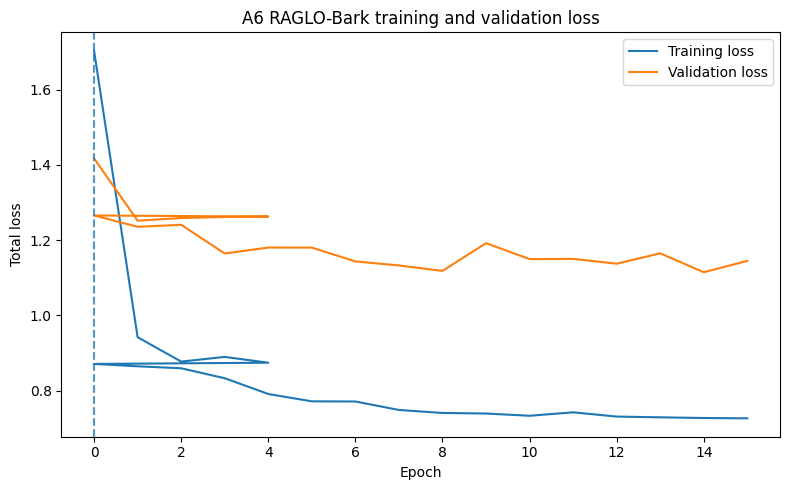

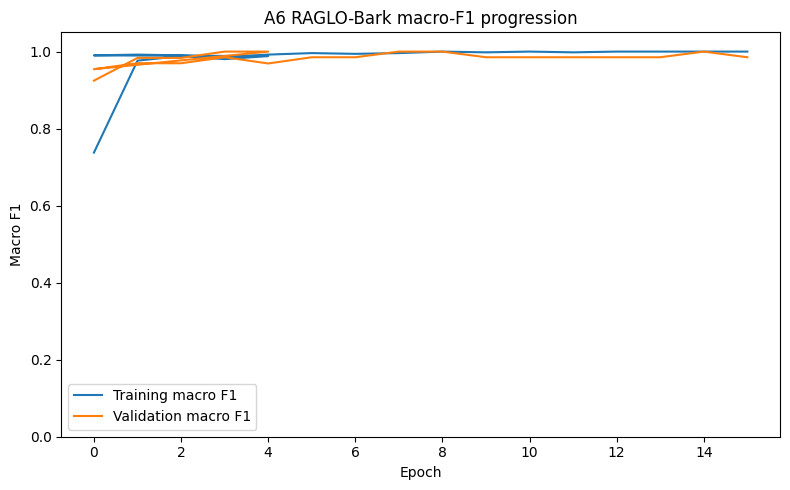

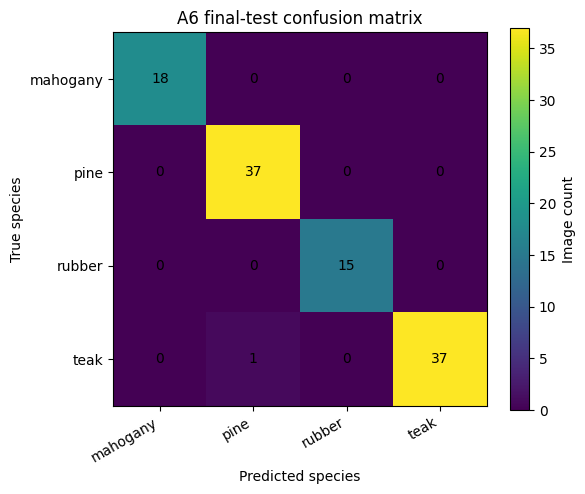

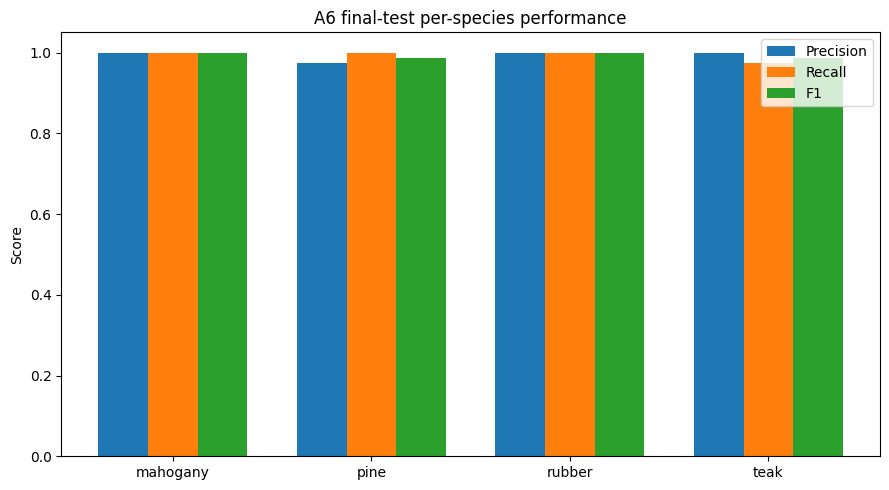

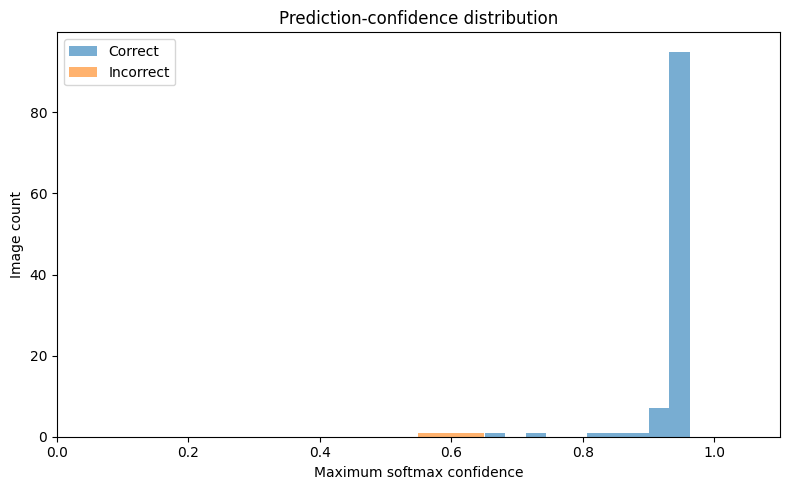

Closed-set figures saved to: /content/drive/MyDrive/RAGLO_Bark/outputs/figures


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

A6_HISTORY_PATH = REPORT_ROOT / "ablation_a6_history.csv"
FINAL_METRICS_PATH = REPORT_ROOT / "final_test_metrics.json"
FINAL_PREDICTIONS_PATH = REPORT_ROOT / "final_test_predictions.csv"

if not A6_HISTORY_PATH.exists():
    raise FileNotFoundError(A6_HISTORY_PATH)
if not FINAL_METRICS_PATH.exists():
    raise FileNotFoundError(FINAL_METRICS_PATH)
if not FINAL_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(FINAL_PREDICTIONS_PATH)

a6_history = pd.read_csv(A6_HISTORY_PATH)
closed_metrics = json.loads(FINAL_METRICS_PATH.read_text())
closed_predictions = pd.read_csv(FINAL_PREDICTIONS_PATH)

# Graph 1: A6 total loss curves.
plt.figure(figsize=(8, 5))
plt.plot(a6_history["epoch"], a6_history["train_loss_total"], label="Training loss")
plt.plot(a6_history["epoch"], a6_history["val_loss_total"], label="Validation loss")
for phase, group in a6_history.groupby("phase"):
    first_epoch = group["epoch"].min()
    plt.axvline(first_epoch, linestyle="--", alpha=0.5)
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.title("A6 RAGLO-Bark training and validation loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_ROOT / "a6_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# Graph 2: A6 macro-F1 curves.
plt.figure(figsize=(8, 5))
plt.plot(a6_history["epoch"], a6_history["train_macro_f1"], label="Training macro F1")
plt.plot(a6_history["epoch"], a6_history["val_macro_f1"], label="Validation macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.title("A6 RAGLO-Bark macro-F1 progression")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_ROOT / "a6_macro_f1_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# Graph 3: count confusion matrix.
confusion = np.asarray(closed_metrics["confusion_matrix"])
plt.figure(figsize=(6, 5))
plt.imshow(confusion)
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=30, ha="right")
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.xlabel("Predicted species")
plt.ylabel("True species")
plt.title("A6 final-test confusion matrix")
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        plt.text(column, row, int(confusion[row, column]), ha="center", va="center")
plt.colorbar(label="Image count")
plt.tight_layout()
plt.savefig(FIGURE_ROOT / "a6_final_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Graph 4: per-class precision, recall and F1.
per_class = pd.DataFrame(closed_metrics["per_class"]).T
per_class = per_class.loc[CLASS_NAMES]
x = np.arange(len(per_class))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, per_class["precision"], width, label="Precision")
plt.bar(x, per_class["recall"], width, label="Recall")
plt.bar(x + width, per_class["f1"], width, label="F1")
plt.xticks(x, per_class.index)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("A6 final-test per-species performance")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_ROOT / "a6_per_class_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# Graph 5: confidence for correct and incorrect predictions.
correct_confidence = closed_predictions.loc[
    closed_predictions["correct"].astype(bool), "confidence"
]
incorrect_confidence = closed_predictions.loc[
    ~closed_predictions["correct"].astype(bool), "confidence"
]

plt.figure(figsize=(8, 5))
plt.hist(correct_confidence, bins=10, alpha=0.6, label="Correct")
plt.hist(incorrect_confidence, bins=10, alpha=0.6, label="Incorrect")
plt.xlabel("Maximum softmax confidence")
plt.ylabel("Image count")
plt.title("Prediction-confidence distribution")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_ROOT / "a6_confidence_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Closed-set figures saved to:", FIGURE_ROOT)

# 30 — Open-set graphs and statistical confidence intervals

The following analysis is valid only when fresh eucalyptus calibration and test
results were generated during this run.

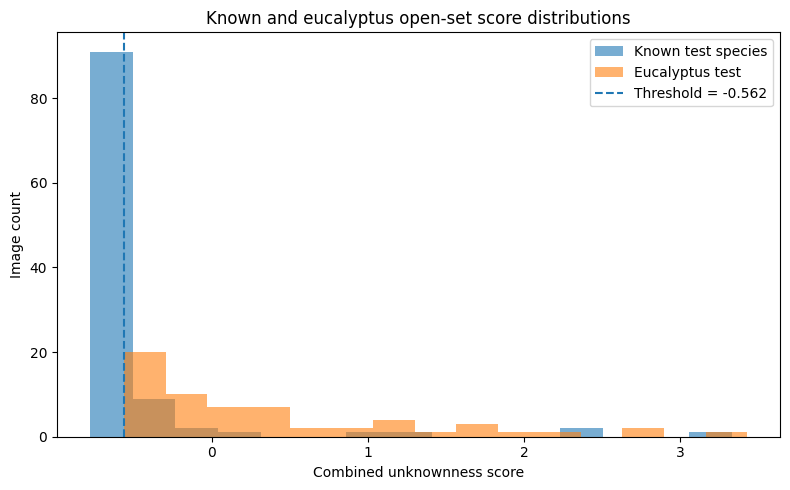

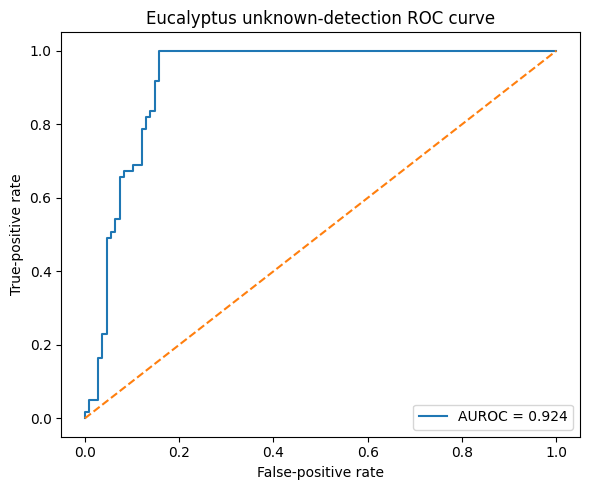

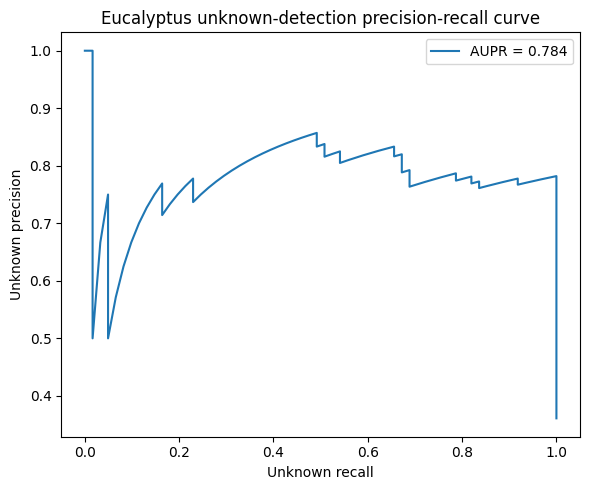

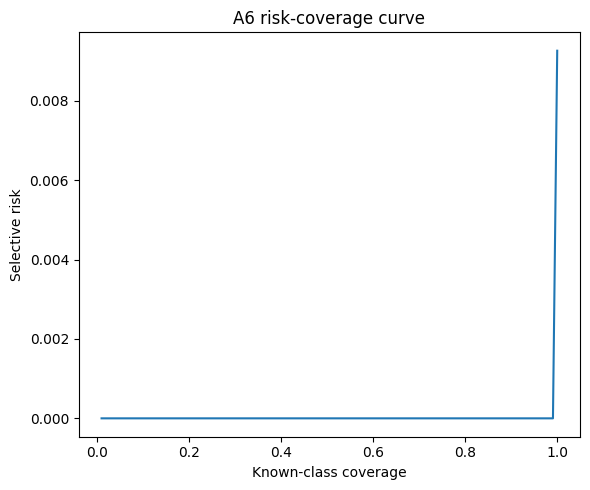

Open-set 95% confidence intervals:
{
  "bootstrap_samples": 2000,
  "auroc_95_ci": [
    0.8797776259866423,
    0.9626631754705525
  ],
  "aupr_95_ci": [
    0.6859990197428102,
    0.9098363587963093
  ],
  "open_set_balanced_accuracy_95_ci": [
    0.872495446265938,
    0.9490740740740741
  ],
  "known_rejection_rate_wilson_95_ci": [
    0.10066202670916789,
    0.23768709015421374
  ],
  "unknown_rejection_rate_wilson_95_ci": [
    0.9128113995535841,
    0.9971002692007002
  ],
  "unknown_false_acceptance_rate_wilson_95_ci": [
    0.002899730799299824,
    0.08718860044641587
  ],
  "known_test_count": 108,
  "eucalyptus_test_count": 61
}
Open-set figures saved to: /content/drive/MyDrive/RAGLO_Bark/outputs/figures


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    balanced_accuracy_score,
)

OPEN_PREDICTIONS_PATH = REPORT_ROOT / "open_set_predictions.csv"
OPEN_METRICS_PATH = REPORT_ROOT / "open_set_metrics.json"
OPEN_BOOTSTRAP_PATH = REPORT_ROOT / "open_set_bootstrap_95_ci.json"

def percentile_interval(values, lower=2.5, upper=97.5):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return [float("nan"), float("nan")]
    return [
        float(np.percentile(values, lower)),
        float(np.percentile(values, upper)),
    ]

def wilson_interval(successes, total, confidence_z=1.959963984540054):
    if total <= 0:
        return [float("nan"), float("nan")]
    proportion = successes / total
    denominator = 1 + confidence_z**2 / total
    center = (
        proportion
        + confidence_z**2 / (2 * total)
    ) / denominator
    margin = (
        confidence_z
        * np.sqrt(
            proportion * (1 - proportion) / total
            + confidence_z**2 / (4 * total**2)
        )
        / denominator
    )
    return [float(max(0, center - margin)), float(min(1, center + margin))]

if not OPEN_PREDICTIONS_PATH.exists() or not OPEN_METRICS_PATH.exists():
    print(
        "Open-set plots skipped. Confirm that both eucalyptus calibration "
        "and eucalyptus test folders contain images."
    )
else:
    open_predictions = pd.read_csv(OPEN_PREDICTIONS_PATH)
    open_metrics = json.loads(OPEN_METRICS_PATH.read_text())
    open_config = json.loads(
        (EXPORT_ROOT / "open_set_calibration.json").read_text()
    )

    truth = open_predictions["is_unknown"].astype(int).to_numpy()
    scores = open_predictions["combined_unknown_score"].to_numpy()
    threshold = float(open_config["threshold"])
    predicted_unknown = scores >= threshold

    known_mask = truth == 0
    unknown_mask = truth == 1

    # Graph 6: known versus eucalyptus unknownness distributions.
    plt.figure(figsize=(8, 5))
    plt.hist(
        scores[known_mask],
        bins=15,
        alpha=0.6,
        label="Known test species",
    )
    plt.hist(
        scores[unknown_mask],
        bins=15,
        alpha=0.6,
        label="Eucalyptus test",
    )
    plt.axvline(
        threshold,
        linestyle="--",
        label=f"Threshold = {threshold:.3f}",
    )
    plt.xlabel("Combined unknownness score")
    plt.ylabel("Image count")
    plt.title("Known and eucalyptus open-set score distributions")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        FIGURE_ROOT / "open_set_score_distributions.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # Graph 7: ROC curve.
    fpr, tpr, _ = roc_curve(truth, scores)
    auroc = roc_auc_score(truth, scores)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.title("Eucalyptus unknown-detection ROC curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_ROOT / "open_set_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Graph 8: precision-recall curve.
    precision, recall, _ = precision_recall_curve(truth, scores)
    aupr = average_precision_score(truth, scores)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPR = {aupr:.3f}")
    plt.xlabel("Unknown recall")
    plt.ylabel("Unknown precision")
    plt.title("Eucalyptus unknown-detection precision-recall curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_ROOT / "open_set_pr_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Graph 9: risk-coverage curve.
    risk_coverage = open_metrics.get("risk_coverage_curve", {})
    coverage_curve = risk_coverage.get("coverage", [])
    risk_curve = risk_coverage.get("selective_risk", [])
    if coverage_curve and risk_curve:
        plt.figure(figsize=(6, 5))
        plt.plot(coverage_curve, risk_curve)
        plt.xlabel("Known-class coverage")
        plt.ylabel("Selective risk")
        plt.title("A6 risk-coverage curve")
        plt.tight_layout()
        plt.savefig(
            FIGURE_ROOT / "open_set_risk_coverage_curve.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    # Stratified bootstrap intervals.
    rng = np.random.default_rng(CFG.RANDOM_SEED)
    known_indices = np.flatnonzero(known_mask)
    unknown_indices = np.flatnonzero(unknown_mask)
    bootstrap_rows = []

    for _ in range(CFG.BOOTSTRAP_SAMPLES):
        sampled_known = rng.choice(
            known_indices,
            size=len(known_indices),
            replace=True,
        )
        sampled_unknown = rng.choice(
            unknown_indices,
            size=len(unknown_indices),
            replace=True,
        )
        sampled_indices = np.r_[sampled_known, sampled_unknown]
        sampled_truth = truth[sampled_indices]
        sampled_scores = scores[sampled_indices]
        sampled_predictions = sampled_scores >= threshold

        bootstrap_rows.append(
            {
                "auroc": roc_auc_score(sampled_truth, sampled_scores),
                "aupr": average_precision_score(
                    sampled_truth,
                    sampled_scores,
                ),
                "balanced_accuracy": balanced_accuracy_score(
                    sampled_truth,
                    sampled_predictions,
                ),
            }
        )

    bootstrap_frame = pd.DataFrame(bootstrap_rows)

    known_rejections = int(predicted_unknown[known_mask].sum())
    unknown_rejections = int(predicted_unknown[unknown_mask].sum())
    unknown_false_acceptances = int((~predicted_unknown[unknown_mask]).sum())

    intervals = {
        "bootstrap_samples": int(CFG.BOOTSTRAP_SAMPLES),
        "auroc_95_ci": percentile_interval(bootstrap_frame["auroc"]),
        "aupr_95_ci": percentile_interval(bootstrap_frame["aupr"]),
        "open_set_balanced_accuracy_95_ci": percentile_interval(
            bootstrap_frame["balanced_accuracy"]
        ),
        "known_rejection_rate_wilson_95_ci": wilson_interval(
            known_rejections,
            int(known_mask.sum()),
        ),
        "unknown_rejection_rate_wilson_95_ci": wilson_interval(
            unknown_rejections,
            int(unknown_mask.sum()),
        ),
        "unknown_false_acceptance_rate_wilson_95_ci": wilson_interval(
            unknown_false_acceptances,
            int(unknown_mask.sum()),
        ),
        "known_test_count": int(known_mask.sum()),
        "eucalyptus_test_count": int(unknown_mask.sum()),
    }

    OPEN_BOOTSTRAP_PATH.write_text(
        json.dumps(intervals, indent=2)
    )
    print("Open-set 95% confidence intervals:")
    print(json.dumps(intervals, indent=2))
    print("Open-set figures saved to:", FIGURE_ROOT)

# 31 — Report-ready evaluation table and summary

This cell combines the closed-set and eucalyptus open-set results into files that
can be copied directly into the evaluation chapter.

# Additional report-ready model diagnostics

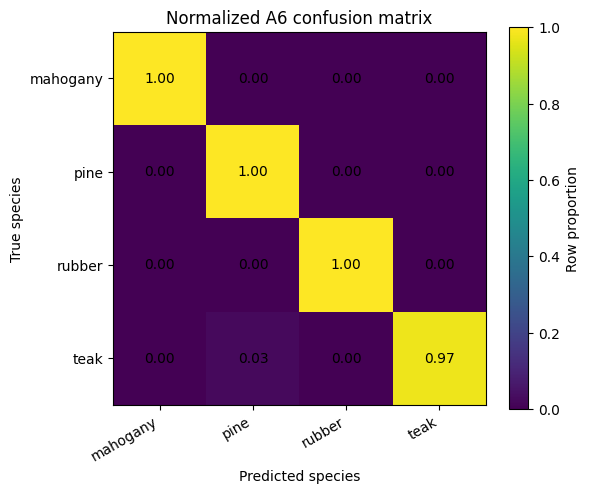

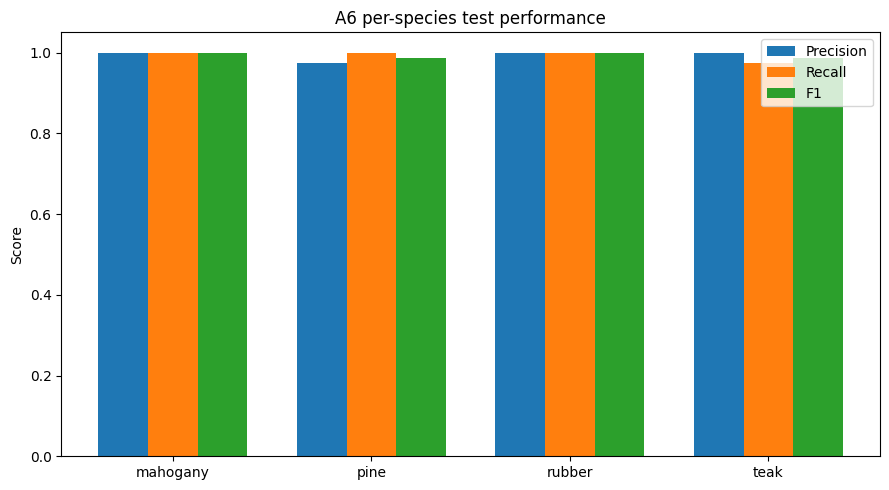

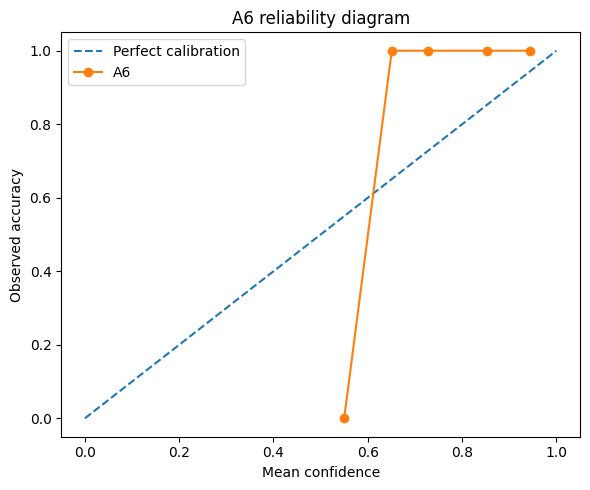

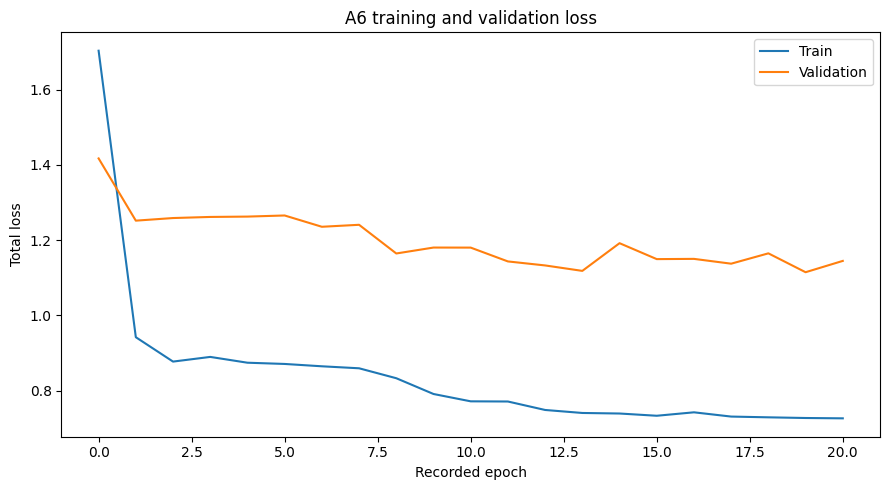

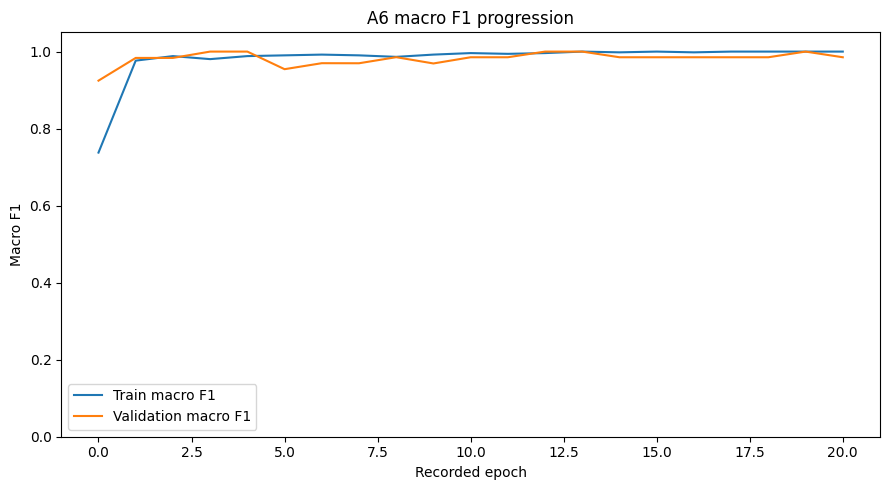

In [ ]:
from sklearn.decomposition import PCA
if final_predictions is not None and final_metrics is not None:
    cm=np.asarray(final_metrics["confusion_matrix"]); normalized=np.divide(cm,cm.sum(1,keepdims=True),out=np.zeros_like(cm,dtype=float),where=cm.sum(1,keepdims=True)!=0)
    plt.figure(figsize=(6,5)); plt.imshow(normalized,vmin=0,vmax=1); plt.xticks(range(4),CLASS_NAMES,rotation=30,ha="right"); plt.yticks(range(4),CLASS_NAMES); plt.xlabel("Predicted species"); plt.ylabel("True species"); plt.title("Normalized A6 confusion matrix")
    for r in range(4):
        for col in range(4): plt.text(col,r,f"{normalized[r,col]:.2f}",ha="center",va="center")
    plt.colorbar(label="Row proportion"); plt.tight_layout(); plt.savefig(FIGURE_ROOT/"a6_confusion_matrix_normalized.png",dpi=300,bbox_inches="tight"); plt.show()
    per_class=pd.DataFrame(final_metrics["per_class"]).T.reindex(CLASS_NAMES); x=np.arange(4); width=.25
    plt.figure(figsize=(9,5)); plt.bar(x-width,per_class.precision,width,label="Precision"); plt.bar(x,per_class.recall,width,label="Recall"); plt.bar(x+width,per_class.f1,width,label="F1"); plt.xticks(x,CLASS_NAMES); plt.ylim(0,1.05); plt.ylabel("Score"); plt.title("A6 per-species test performance"); plt.legend(); plt.tight_layout(); plt.savefig(FIGURE_ROOT/"a6_per_class_metrics.png",dpi=300,bbox_inches="tight"); plt.show(); per_class.to_csv(REPORT_ROOT/"final_test_per_class_metrics.csv")
    if reliability_frame is not None:
        valid=reliability_frame.dropna(subset=["mean_confidence","accuracy"]); plt.figure(figsize=(6,5)); plt.plot([0,1],[0,1],"--",label="Perfect calibration"); plt.plot(valid.mean_confidence,valid.accuracy,marker="o",label="A6"); plt.xlabel("Mean confidence"); plt.ylabel("Observed accuracy"); plt.title("A6 reliability diagram"); plt.legend(); plt.tight_layout(); plt.savefig(FIGURE_ROOT/"a6_reliability_diagram.png",dpi=300,bbox_inches="tight"); plt.show()
if not a6_history.empty:
    plt.figure(figsize=(9,5)); plt.plot(np.arange(len(a6_history)),a6_history.train_loss_total,label="Train"); plt.plot(np.arange(len(a6_history)),a6_history.val_loss_total,label="Validation"); plt.xlabel("Recorded epoch"); plt.ylabel("Total loss"); plt.title("A6 training and validation loss"); plt.legend(); plt.tight_layout(); plt.savefig(FIGURE_ROOT/"a6_training_validation_loss.png",dpi=300,bbox_inches="tight"); plt.show()
    plt.figure(figsize=(9,5)); plt.plot(np.arange(len(a6_history)),a6_history.train_macro_f1,label="Train macro F1"); plt.plot(np.arange(len(a6_history)),a6_history.val_macro_f1,label="Validation macro F1"); plt.xlabel("Recorded epoch"); plt.ylabel("Macro F1"); plt.ylim(0,1.05); plt.title("A6 macro F1 progression"); plt.legend(); plt.tight_layout(); plt.savefig(FIGURE_ROOT/"a6_macro_f1_progression.png",dpi=300,bbox_inches="tight"); plt.show()

# Optional Gradio prototype web application

In [ ]:
if CFG.RUN_GRADIO_DEMO:
    import gradio as gr, tempfile
    def web_predict(image):
        if image is None: return {"status":"error","message":"Upload a bark image."}
        with tempfile.NamedTemporaryFile(suffix=".jpg",delete=False) as handle: path=Path(handle.name)
        image.save(path)
        try: return predict_bark_image(path,a6_model,CLASS_NAMES,class_prototypes,open_set_config,commercial_kb,"multiscale")
        finally: path.unlink(missing_ok=True)
    demo=gr.Interface(fn=web_predict,inputs=gr.Image(type="pil",label="Bark image"),outputs=gr.JSON(label="RAGLO-Bark result"),title="RAGLO-Bark A6 Prototype",description="Known species / unknown / uncertain. Expert verification required.")
    demo.launch(share=True)
else: print("Gradio prototype disabled.")

Gradio prototype disabled.


In [ ]:
report_rows = []

report_rows.extend(
    [
        {"evaluation": "Closed-set", "metric": "Accuracy", "value": closed_metrics["accuracy"]},
        {"evaluation": "Closed-set", "metric": "Macro precision", "value": closed_metrics["macro_precision"]},
        {"evaluation": "Closed-set", "metric": "Macro recall", "value": closed_metrics["macro_recall"]},
        {"evaluation": "Closed-set", "metric": "Macro F1", "value": closed_metrics["macro_f1"]},
        {"evaluation": "Closed-set", "metric": "Balanced accuracy", "value": closed_metrics["balanced_accuracy"]},
        {"evaluation": "Closed-set", "metric": "Cohen kappa", "value": closed_metrics["cohen_kappa"]},
        {"evaluation": "Closed-set", "metric": "Matthews correlation coefficient", "value": closed_metrics["mcc"]},
    ]
)

if OPEN_METRICS_PATH.exists():
    open_metrics = json.loads(OPEN_METRICS_PATH.read_text())
    report_rows.extend(
        [
            {"evaluation": "Eucalyptus open-set", "metric": "AUROC", "value": open_metrics["unknown_detection_auroc"]},
            {"evaluation": "Eucalyptus open-set", "metric": "AUPR", "value": open_metrics["unknown_detection_aupr"]},
            {"evaluation": "Eucalyptus open-set", "metric": "Open-set balanced accuracy", "value": open_metrics["open_set_balanced_accuracy"]},
            {"evaluation": "Eucalyptus open-set", "metric": "Known-species rejection rate", "value": open_metrics["known_species_rejection_rate"]},
            {"evaluation": "Eucalyptus open-set", "metric": "Unknown false-acceptance rate", "value": open_metrics["unknown_species_false_acceptance_rate"]},
            {"evaluation": "Eucalyptus open-set", "metric": "Coverage", "value": open_metrics["coverage"]},
            {"evaluation": "Eucalyptus open-set", "metric": "Selective accuracy", "value": open_metrics["selective_accuracy"]},
        ]
    )

report_table = pd.DataFrame(report_rows)
report_table.to_csv(
    REPORT_ROOT / "final_report_metrics_table.csv",
    index=False,
)
display(report_table)

summary_lines = [
    "RAGLO-Bark final evaluation summary",
    "===================================",
    f"Known-class test accuracy: {closed_metrics['accuracy']:.4f}",
    f"Known-class macro F1: {closed_metrics['macro_f1']:.4f}",
    f"Known-class balanced accuracy: {closed_metrics['balanced_accuracy']:.4f}",
]

if OPEN_METRICS_PATH.exists():
    summary_lines.extend(
        [
            f"Eucalyptus unknown-detection AUROC: {open_metrics['unknown_detection_auroc']:.4f}",
            f"Eucalyptus unknown-detection AUPR: {open_metrics['unknown_detection_aupr']:.4f}",
            f"Open-set balanced accuracy: {open_metrics['open_set_balanced_accuracy']:.4f}",
            f"Known-species rejection rate: {open_metrics['known_species_rejection_rate']:.4f}",
            f"Eucalyptus false-acceptance rate: {open_metrics['unknown_species_false_acceptance_rate']:.4f}",
            "",
            "Scope limitation: eucalyptus was the only available unknown species. "
            "The result demonstrates eucalyptus rejection and does not establish "
            "general rejection of every unseen tree species.",
        ]
    )

summary_text = "\n".join(summary_lines)
(REPORT_ROOT / "final_report_evaluation_summary.txt").write_text(summary_text)
print(summary_text)

,evaluation,metric,value
0,Closed-set,Accuracy,0.990741
1,Closed-set,Macro precision,0.993421
2,Closed-set,Macro recall,0.993421
3,Closed-set,Macro F1,0.993333
4,Closed-set,Balanced accuracy,0.993421
5,Closed-set,Cohen kappa,0.986993
6,Closed-set,Matthews correlation coefficient,0.987112
7,Eucalyptus open-set,AUROC,0.923953
8,Eucalyptus open-set,AUPR,0.784277
9,Eucalyptus open-set,Open-set balanced accuracy,0.913100


RAGLO-Bark final evaluation summary
Known-class test accuracy: 0.9907
Known-class macro F1: 0.9933
Known-class balanced accuracy: 0.9934
Eucalyptus unknown-detection AUROC: 0.9240
Eucalyptus unknown-detection AUPR: 0.7843
Open-set balanced accuracy: 0.9131
Known-species rejection rate: 0.1574
Eucalyptus false-acceptance rate: 0.0164

Scope limitation: eucalyptus was the only available unknown species. The result demonstrates eucalyptus rejection and does not establish general rejection of every unseen tree species.


# 29 — Patch-attention visualization

In [ ]:
def visualize_patch_attention(image_path,model):
    if not isinstance(model,RAGLOBarkModel):
        print("Patch attention is not available for global-only baselines."); return
    image=load_rgb_image(Path(image_path)); patches,_=extract_four_patches(image,False)
    global_tensor=DETERMINISTIC_TENSOR(aspect_resize_pad(image,CFG.GLOBAL_IMAGE_SIZE)).unsqueeze(0).to(DEVICE)
    local_tensor=torch.stack([DETERMINISTIC_TENSOR(aspect_resize_pad(p,CFG.LOCAL_IMAGE_SIZE)) for p in patches]).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.inference_mode():
        output=model(global_tensor,local_tensor); probability=F.softmax(output["fused_logits"],1); confidence,prediction=probability.max(1); attention=output["attention_weights"][0].cpu().numpy()
    fig,axes=plt.subplots(1,5,figsize=(16,4),squeeze=False); axes=axes[0]; axes[0].imshow(image); axes[0].set_title(f"{CLASS_NAMES[prediction.item()]} ({confidence.item():.3f})")
    winner=int(attention.argmax())
    for index,(patch,weight) in enumerate(zip(patches,attention)):
        axes[index+1].imshow(patch); axes[index+1].set_title(f"Patch {index+1}: {weight:.3f}")
        for spine in axes[index+1].spines.values(): spine.set_edgecolor("red" if index==winner else "black"); spine.set_linewidth(4 if index==winner else 1)
    for axis in axes: axis.set_xticks([]); axis.set_yticks([])
    target=FIGURE_ROOT/"patch_attention"; target.mkdir(exist_ok=True); plt.tight_layout(); plt.savefig(target/(Path(image_path).stem+".png"),dpi=180); plt.show()

# 30 — Global saliency

In [ ]:
def global_gradient_saliency(model,global_tensor,local_tensor):
    model.eval(); x=global_tensor.detach().clone().requires_grad_(True); model.zero_grad(set_to_none=True)
    out=model(x,local_tensor); predicted=out["fused_logits"].argmax(1); out["fused_logits"][0,predicted.item()].backward()
    saliency=x.grad.detach().abs().amax(1)[0]; saliency=(saliency-saliency.min())/(saliency.max()-saliency.min()+1e-8)
    return saliency.cpu(),predicted.item()
print("Explainability warning: saliency must be reviewed by a forestry expert and is not biological causality.")

Explainability warning: saliency must be reviewed by a forestry expert and is not biological causality.


# 31 — Separate commercial knowledge layer

In [ ]:
COMMERCIAL_KB_PATH=PROJECT_ROOT/"commercial_knowledge_base.csv"
KB_COLUMNS=["species","scientific_name","official_timber_class","commercial_potential","typical_uses","treatment_dependency","source_name","source_date","requires_expert_verification"]
if COMMERCIAL_KB_PATH.exists(): commercial_kb=pd.read_csv(COMMERCIAL_KB_PATH)
else:
    commercial_kb=pd.DataFrame(columns=KB_COLUMNS); commercial_kb.to_csv(REPORT_ROOT/"commercial_knowledge_base_template.csv",index=False)
    print("Commercial KB absent; blank template created. No classifications invented.")
def lookup_commercial_information(species_name,knowledge_base=None):
    kb=commercial_kb if knowledge_base is None else knowledge_base
    if species_name is None: return {"commercial_potential":"not_determined"}
    match=kb[kb.species.astype(str).str.lower()==species_name.lower()] if len(kb) else kb
    if match.empty: return {"species":species_name,"commercial_potential":"not_configured","requires_expert_verification":True}
    return match.iloc[0].to_dict()
print("Exact value also requires diameter, merchantable height, condition, treatment, market price, and legal verification.")

Commercial KB absent; blank template created. No classifications invented.
Exact value also requires diameter, merchantable height, condition, treatment, market price, and legal verification.


# 32 — Single-image inference

In [ ]:
def prepare_inference_inputs(image_path,model_type):
    path=Path(image_path)
    if not path.is_file(): raise FileNotFoundError(f"Inference image not found: {path}")
    image=load_rgb_image(path); global_tensor=DETERMINISTIC_TENSOR(aspect_resize_pad(image,CFG.GLOBAL_IMAGE_SIZE)).unsqueeze(0).to(DEVICE)
    inputs={"global_image":global_tensor}; patches=[]
    if model_type=="multiscale":
        patches,_=extract_four_patches(image,False); assert len(patches)==CFG.NUMBER_OF_PATCHES
        inputs["local_patches"]=torch.stack([DETERMINISTIC_TENSOR(aspect_resize_pad(p,CFG.LOCAL_IMAGE_SIZE)) for p in patches]).unsqueeze(0).to(DEVICE)
    return inputs,patches

def predict_bark_image(image_path,model,class_names,prototypes=None,open_set_config=None,commercial_kb=None,model_type="multiscale"):
    """JSON-safe known/unknown inference for both global and multiscale models."""
    inputs,_=prepare_inference_inputs(image_path,model_type); model.eval()
    with torch.inference_mode(): output=model(**inputs); probabilities=F.softmax(output["fused_logits"],1); confidence,index=probabilities.max(1)
    status="known"; proto_min=combined=None; distances=[]; energy=None
    if open_set_config is not None:
        if prototypes is None or "embedding" not in output: warnings.warn("Open-set calibration ignored: compatible embeddings/prototypes are unavailable.")
        else:
            temperature=float(open_set_config.get("energy_temperature",CFG.ENERGY_TEMPERATURE))
            energy=float(energy_score(output["fused_logits"],temperature)[0]); _,minimum,all_dist=prototype_distances(output["embedding"].cpu(),prototypes.cpu())
            proto_min=float(minimum[0]); distances=[float(value) for value in all_dist[0]]
            combined=float(combined_unknownness([proto_min],[energy],open_set_config)[0]); threshold=float(open_set_config["threshold"]); margin=float(open_set_config.get("uncertainty_margin",0.05))
            status="unknown" if combined>threshold+margin else ("uncertain" if abs(combined-threshold)<=margin else "known")
    species=class_names[int(index)] if status=="known" else None
    attention=output.get("attention_weights",torch.full((1,CFG.NUMBER_OF_PATCHES),1/CFG.NUMBER_OF_PATCHES,device=DEVICE))[0]
    return {"status":status,"species":species,"scientific_name":SCIENTIFIC_NAMES.get(species) if species else None,"confidence":float(confidence[0]),
      "prototype_distance":proto_min,"all_prototype_distances":distances,"energy_score":energy,"combined_unknown_score":combined,
      "attention_weights":[float(value) for value in attention.detach().cpu()],
      "commercial_information":lookup_commercial_information(species,commercial_kb) if status=="known" else {"commercial_potential":"not_determined"}}

# 33 — Interactive Colab image upload

In [ ]:
RUN_INTERACTIVE_INFERENCE = CFG.RUN_INTERACTIVE_INFERENCE

if RUN_INTERACTIVE_INFERENCE:
    inference_model = a6_model

    from google.colab import files

    uploaded = files.upload()

    if len(uploaded) != 1:
        raise ValueError("Upload exactly one image")

    uploaded_name = next(iter(uploaded))
    upload_path = Path("/content") / uploaded_name
    upload_path.write_bytes(uploaded[uploaded_name])

    result = predict_bark_image(
        upload_path,
        inference_model,
        CLASS_NAMES,
        class_prototypes,
        open_set_config,
        commercial_kb,
        model_type="multiscale",
    )

    print(json.dumps(result, indent=2))
    visualize_patch_attention(
        upload_path,
        inference_model,
    )
    print("Expert confirmation is required.")
else:
    print("Interactive upload disabled.")

Interactive upload disabled.


# 34 — Export complete RAGLO artifact

In [ ]:
from safetensors.torch import save_file
from transformers import Dinov2Config, Dinov2Model
DEPLOYMENT_ARTIFACT_PATH=EXPORT_ROOT/"raglo_bark_a6_deployment.pt"
SAFETENSORS_PATH=EXPORT_ROOT/"raglo_bark_a6_weights.safetensors"
DEPLOYMENT_MANIFEST_PATH=EXPORT_ROOT/"deployment_manifest.json"

def cpu_state_dict(model): return {k:v.detach().cpu().contiguous() for k,v in model.state_dict().items()}

def export_complete_artifact(model,signature,prototypes=None,calibration=None,best_metrics=None):
    state=cpu_state_dict(model)
    artifact={"artifact_version":"1.0","architecture":{"name":"RAGLO-Bark","ablation":"A6","global_encoder":DINO_MODEL_ID,
      "global_encoder_config":model.global_encoder.config.to_dict(),"local_encoder":CONVNEXT_MODEL_ID,"embedding_dimension":CFG.EMBEDDING_DIM,
      "use_attention":True,"fusion_mode":"gated"},"model_state_dict":state,"class_names":CLASS_NAMES,"class_to_idx":CLASS_TO_IDX,"scientific_names":SCIENTIFIC_NAMES,
      "preprocessing":{"global_size":CFG.GLOBAL_IMAGE_SIZE,"local_size":CFG.LOCAL_IMAGE_SIZE,"mean":IMAGENET_MEAN,"std":IMAGENET_STD,"resize":"aspect_fit_then_neutral_pad"},
      "patch_settings":{"count":CFG.NUMBER_OF_PATCHES,"layout":"2x2","fraction":0.58},"class_prototypes":prototypes.cpu() if prototypes is not None else None,
      "open_set_configuration":calibration,"dataset_version":{"rows":len(metadata),"metadata_hash":metadata_digest(metadata),"protocol":"redundancy-controlled image-level"},
      "best_validation_metrics":best_metrics,"closed_set_metrics":final_metrics,"open_set_metrics":globals().get("metrics_open"),"experiment_signature":signature,
      "checkpoint":{"path":str(A6_CHECKPOINT),"sha256":checkpoint_hash},"training_summary":training_summary}
    torch.save(artifact,DEPLOYMENT_ARTIFACT_PATH); save_file(state,str(SAFETENSORS_PATH))
    manifest={k:v for k,v in artifact.items() if k not in ["model_state_dict","class_prototypes"]}; manifest.update({"artifact_path":str(DEPLOYMENT_ARTIFACT_PATH),"artifact_sha256":file_sha256(DEPLOYMENT_ARTIFACT_PATH),"artifact_size_mb":DEPLOYMENT_ARTIFACT_PATH.stat().st_size/2**20,"safetensors_path":str(SAFETENSORS_PATH),"safetensors_sha256":file_sha256(SAFETENSORS_PATH)})
    DEPLOYMENT_MANIFEST_PATH.write_text(json.dumps(manifest,indent=2,default=str)); (EXPORT_ROOT/"requirements_deployment.txt").write_text("torch\ntorchvision\ntimm\ntransformers\nPillow\nnumpy\nsafetensors\ngradio\n")
    return artifact

deployment_artifact=None
if CFG.RUN_EXPORT:
    best_metrics=None
    if not a6_history.empty:
        best_row=a6_history.sort_values(["val_macro_f1","val_loss_total"],ascending=[False,True]).iloc[0]
        best_metrics={"phase":str(best_row.phase),"epoch":int(best_row.epoch),"validation_macro_f1":float(best_row.val_macro_f1),"validation_accuracy":float(best_row.val_accuracy),"validation_balanced_accuracy":float(best_row.val_balanced_accuracy),"validation_loss_total":float(best_row.val_loss_total)}
    deployment_artifact=export_complete_artifact(a6_model,a6_signature,class_prototypes,open_set_config,best_metrics)
    print("Deployment artifact:",DEPLOYMENT_ARTIFACT_PATH,"MiB:",round(DEPLOYMENT_ARTIFACT_PATH.stat().st_size/2**20,2))
else: print("Export disabled.")

Deployment artifact: /content/drive/MyDrive/RAGLO_Bark/outputs/exported_model/raglo_bark_a6_deployment.pt MiB: 99.66


# 35 — Export/reload verification

In [ ]:
def build_model_from_artifact(artifact):
    global_encoder=Dinov2Model(Dinov2Config.from_dict(artifact["architecture"]["global_encoder_config"]))
    local_encoder=timm.create_model(artifact["architecture"]["local_encoder"],pretrained=False,num_classes=0,global_pool="avg")
    model=RAGLOBarkModel(num_classes=len(artifact["class_names"]),embedding_dim=artifact["architecture"]["embedding_dimension"],pretrained=False,
      global_encoder=global_encoder,local_encoder=local_encoder,use_attention=True,fusion_mode="gated")
    model.load_state_dict(artifact["model_state_dict"]); return model.to(DEVICE).eval()

reload_checks=None
if CFG.RUN_EXPORT and CFG.VERIFY_EXPORT:
    fresh_model=build_model_from_artifact(deployment_artifact); sample=next(iter(multiscale_loaders["model_validation"])); inputs={k:v[:1].to(DEVICE) for k,v in sample.items() if k in ["global_image","local_patches"]}
    a6_model.eval()
    with torch.inference_mode(): first=a6_model(**inputs); second=fresh_model(**inputs)
    reload_checks={"same_prediction":first["fused_logits"].argmax(1).item()==second["fused_logits"].argmax(1).item(),
      "same_logits":bool(torch.allclose(first["fused_logits"],second["fused_logits"],atol=1e-6)),"same_embedding":bool(torch.allclose(first["embedding"],second["embedding"],atol=1e-6)),
      "same_attention":bool(torch.allclose(first["attention_weights"],second["attention_weights"],atol=1e-6)),"same_mapping":deployment_artifact["class_to_idx"]==CLASS_TO_IDX}
    (EXPORT_ROOT/"reload_verification.json").write_text(json.dumps(reload_checks,indent=2)); print(reload_checks); assert all(reload_checks.values())
else: print("Reload verification disabled or export unavailable.")

{'same_prediction': True, 'same_logits': True, 'same_embedding': True, 'same_attention': True, 'same_mapping': True}


## Deployment verification criteria

The deployment artifact is ready for prototype use only when every value in `reload_verification.json` is `true`, the exact ConvNeXt identifier is recorded in `deployment_manifest.json`, and open-set calibration was created from the current checkpoint.

# 36 — Automatic research summary

In [ ]:
summary={"model":"RAGLO-Bark A6","training_summary":training_summary,"closed_set_metrics":final_metrics,"open_set_metrics":globals().get("metrics_open"),"deployment_artifact":str(DEPLOYMENT_ARTIFACT_PATH) if DEPLOYMENT_ARTIFACT_PATH.exists() else None,"reload_verification":reload_checks,"limitations":["Physical-tree identities unavailable: redundancy-controlled image-level evaluation only.","Eucalyptus is the only evaluated unknown species.","External field validation across new trees, cameras and conditions is required."]}
(REPORT_ROOT/"final_research_summary.json").write_text(json.dumps(summary,indent=2,default=str)); print(json.dumps(summary,indent=2,default=str))

{
  "model": "RAGLO-Bark A6",
  "training_summary": {
    "model": "RAGLO-Bark A6",
    "checkpoint_path": "/content/drive/MyDrive/RAGLO_Bark/outputs/checkpoints/raglo_a6_best.pt",
    "checkpoint_sha256": "eb4e82e4f2684fd6b8ab73d7de1071fab33fbc35ec1606bfd251c572a97e98e5",
    "checkpoint_size_mb": 146.15465545654297,
    "parameter_count": 26088341,
    "duration_or_load_seconds": 44.31050781199997,
    "mean_inference_time_ms_per_image": 18.369333931250033,
    "configuration": {
      "RANDOM_SEED": 42,
      "GLOBAL_IMAGE_SIZE": 384,
      "LOCAL_IMAGE_SIZE": 224,
      "NUMBER_OF_PATCHES": 4,
      "BATCH_SIZE": 16,
      "CLASSES_PER_BATCH": 4,
      "SAMPLES_PER_CLASS": 4,
      "NUM_WORKERS": 2,
      "HEAD_WARMUP_EPOCHS": 5,
      "MAX_EPOCHS": 50,
      "EARLY_STOPPING_PATIENCE": 8,
      "BACKBONE_LR": 1e-05,
      "HEAD_LR": 0.0003,
      "WEIGHT_DECAY": 0.0001,
      "LABEL_SMOOTHING": 0.1,
      "GRADIENT_CLIP_NORM": 1.0,
      "SUPCON_WEIGHT": 0.3,
      "CONSISTENCY_WEI

# 37 — Final comparison table

In [ ]:
if MODEL_COMPARISON_PATH.exists():
    model_comparison=pd.read_csv(MODEL_COMPARISON_PATH)
else:
    model_comparison=pd.DataFrame(columns=MODEL_COMPARISON_COLUMNS); model_comparison.to_csv(MODEL_COMPARISON_PATH,index=False)
display(model_comparison.sort_values("validation_macro_f1",ascending=False,na_position="last"))
print("Test fields remain empty until the single officially unlocked evaluation records them.")

,experiment_name,model_name,input_type,attention_enabled,supcon_enabled,consistency_enabled,best_phase,best_epoch,validation_accuracy,validation_macro_f1,validation_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy,parameter_count,training_duration_seconds,mean_inference_time_ms,checkpoint_path,test_evaluated
1,resnet50_baseline,resnet50,global,False,False,False,single,7,1.000000,1.000000,1.000000,NaN,NaN,NaN,23516228,2017.392512,8.552160,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
2,raglo_bark,raglo_bark,global+local,True,True,True,partial,3,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,2439.348201,25.238402,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
3,dinov2_global_baseline,dinov2_global,global,False,False,False,warmup,1,1.000000,1.000000,1.000000,NaN,NaN,NaN,22254468,7781.475027,719.686839,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
4,A3,raglo_bark,global+local,False,False,False,partial,1,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,1939.644199,18.574883,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
6,A5,raglo_bark,global+local,True,True,False,partial,2,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,2699.496741,18.431248,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
5,A4,raglo_bark,global+local,True,False,False,partial,8,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,3930.373012,20.269626,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
7,A6,raglo_bark,global+local,True,True,True,warmup,3,1.000000,1.000000,1.000000,NaN,NaN,NaN,26088341,64.547453,18.644013,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False
0,convnextv2_atto_baseline,convnextv2_atto,global,False,False,False,single,7,0.987013,0.983378,0.977273,NaN,NaN,NaN,3388684,1746.691611,4.166253,/content/drive/MyDrive/RAGLO_Bark/outputs/chec...,False


Test fields remain empty until the single officially unlocked evaluation records them.


# 38 — Lightweight pipeline tests

In [ ]:
def run_raglo_lightweight_tests():
    passed = []

    def check(name, condition):
        assert condition, name
        passed.append(name)

    check(
        "class order",
        CLASS_NAMES
        == ["mahogany", "pine", "rubber", "teak"],
    )

    validate_metadata(metadata, DATASET_ROOT)

    active = metadata[
        metadata.split.isin(
            ["train", "validation", "test"]
        )
    ]

    check(
        "redundancy leakage",
        active.groupby("redundancy_group")
        .split.nunique()
        .max()
        == 1,
    )
    check(
        "hash leakage",
        active.groupby("exact_hash")
        .split.nunique()
        .max()
        == 1,
    )

    rectangle = Image.new(
        "RGB",
        (400, 200),
        (10, 20, 30),
    )
    prepared = aspect_resize_pad(rectangle, 224)
    check("aspect-preserved size", prepared.size == (224, 224))

    patches, _ = extract_four_patches(rectangle)
    check("four patches", len(patches) == 4)

    sample = BarkMultiScaleDataset(
        metadata.iloc[:1],
        DATASET_ROOT,
    )[0]

    check(
        "global shape",
        sample["global_image"].shape
        == (
            3,
            CFG.GLOBAL_IMAGE_SIZE,
            CFG.GLOBAL_IMAGE_SIZE,
        ),
    )
    check(
        "local shape",
        sample["local_patches"].shape
        == (
            4,
            3,
            CFG.LOCAL_IMAGE_SIZE,
            CFG.LOCAL_IMAGE_SIZE,
        ),
    )

    sampler = ClassBalancedBatchSampler(
        frames["train"].species.map(CLASS_TO_IDX),
        classes_per_batch=4,
        samples_per_class=4,
        seed=42,
    )
    first_indices = next(iter(sampler))
    sampled_labels = (
        frames["train"]
        .species.map(CLASS_TO_IDX)
        .iloc[first_indices]
        .value_counts()
    )
    check(
        "balanced SupCon batch",
        len(sampled_labels) == 4
        and set(sampled_labels.tolist()) == {4},
    )

    tiny = RAGLOBarkModel(
        embedding_dim=32,
        pretrained=False,
        global_encoder=TinyTokenEncoder(16),
        local_encoder=TinyStageEncoder(12),
    ).to(DEVICE).eval()

    with torch.inference_mode():
        output = tiny(
            torch.randn(2, 3, 64, 64, device=DEVICE),
            torch.randn(2, 4, 3, 48, 48, device=DEVICE),
        )

    check(
        "logits",
        output["fused_logits"].shape == (2, 4),
    )
    check(
        "embedding",
        output["embedding"].shape == (2, 32),
    )
    check(
        "attention",
        torch.allclose(
            output["attention_weights"].sum(1),
            torch.ones(2, device=DEVICE),
            atol=1e-5,
        ),
    )
    check(
        "embedding normalization",
        torch.allclose(
            output["embedding"].norm(dim=1),
            torch.ones(2, device=DEVICE),
            atol=1e-5,
        ),
    )

    labels = torch.tensor([0, 0], device=DEVICE)
    check(
        "finite SupCon",
        torch.isfinite(
            supervised_contrastive_loss(
                output["embedding"],
                labels,
            )
        ),
    )
    check(
        "finite consistency",
        torch.isfinite(
            js_consistency_loss(
                output["global_logits"],
                output["local_logits"],
            )
        ),
    )

    print(
        f"{len(passed)} RAGLO lightweight checks passed:",
        passed,
    )

if CFG.FAST_DEV_RUN:
    run_raglo_lightweight_tests()
else:
    print(
        "Set CFG.FAST_DEV_RUN=True to run lightweight tests "
        "without full training."
    )

Set CFG.FAST_DEV_RUN=True to run lightweight tests without full training.


# 39 — Optional real pretrained-model smoke test

In [ ]:

RUN_REAL_MODEL_SMOKE_TEST=CFG.RUN_REAL_MODEL_SMOKE_TEST
if RUN_REAL_MODEL_SMOKE_TEST:
    try:
        real_model=RAGLOBarkModel(pretrained=True).to(DEVICE); real_model.eval()
        with torch.inference_mode(): output=real_model(torch.randn(1,3,CFG.GLOBAL_IMAGE_SIZE,CFG.GLOBAL_IMAGE_SIZE,device=DEVICE),torch.randn(1,4,3,CFG.LOCAL_IMAGE_SIZE,CFG.LOCAL_IMAGE_SIZE,device=DEVICE))
        expected={"fused_logits","global_logits","local_logits","embedding","attention_weights","fusion_gate"}; assert expected==set(output)
        assert output["fused_logits"].shape==(1,4) and output["embedding"].shape==(1,CFG.EMBEDDING_DIM) and output["attention_weights"].shape==(1,4) and output["fusion_gate"].shape==(1,256)
        assert all(torch.isfinite(value).all() for value in output.values()); configure_raglo_phase(real_model,"warmup"); configure_raglo_phase(real_model,"partial")
        print("Real-model smoke test PASS | TIMM:",CONVNEXT_MODEL_ID,"| GPU allocated MiB:",round(torch.cuda.memory_allocated()/2**20,1) if torch.cuda.is_available() else 0)
        del real_model,output
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    except Exception as exc:
        print("Real pretrained smoke test could not complete safely:",repr(exc)); print("Check network/model access and installed TIMM/transformers APIs; no training was attempted.")
else: print("Real pretrained smoke test disabled.")


Real pretrained smoke test disabled.


# 40 — Recommended execution

1. Use `TRAINING_MODE="auto"` for a safe first run.
2. Use `TRAINING_MODE="fresh"` only for an intentional complete retraining.
3. Keep eucalyptus outside the four-class training data.
4. Verify `raglo_bark_a6_deployment.pt` and `reload_verification.json` before using the prototype.
5. Treat unknown and uncertain results as requiring expert review.

# Report-code recommendation

Do not paste this complete notebook into the main body of the report.

In the methodology chapter, include:

1. An architecture diagram.
2. A compact training algorithm or pseudocode.
3. A hyperparameter table.
4. The three loss equations.
5. A statement that A6 was frozen before open-set calibration.
6. The eucalyptus calibration/test protocol.

Place the complete executable notebook in an appendix, repository or electronic
supplementary material.

# Deployment outputs

After a successful run, use these files for the prototype:

- `outputs/exported_model/raglo_bark_a6_deployment.pt`
- `outputs/exported_model/raglo_bark_a6_weights.safetensors`
- `outputs/exported_model/deployment_manifest.json`
- `outputs/exported_model/reload_verification.json`
- `outputs/exported_model/class_prototypes.pt`
- `outputs/exported_model/open_set_calibration.json`

Report figures and metrics are saved under `outputs/figures/` and `outputs/reports/`.